In [1]:
import sqlite3, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import emoji
import nltk
from langdetect import detect, LangDetectException
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from pathlib import Path
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
import hdbscan
from sklearn.feature_extraction.text import TfidfVectorizer
import time
from gensim.models import FastText
from nltk.tokenize import word_tokenize
import nltk
import numpy as np
import umap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 300)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
ROOT = Path.cwd().parent

load_dotenv(ROOT / '.env')
DB_PATH = str(ROOT / 'db' / 'gaming_warehouse.db')
IMAGENES_PATH = str(ROOT / 'Imagenes') + '/'

In [3]:
def Query(query, params=None):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    return df


# EDA

## estado de mis reseñas

In [4]:
df_estado = """
SELECT
    COUNT(*) AS total_resenas,
    COUNT(DISTINCT juego_id) AS juegos_distintos,
    ROUND(100.0 * COUNT(resena_texto) / COUNT(*), 1) AS pct_con_texto,
    ROUND(100.0 * COUNT(recomendado) / COUNT(*), 1) AS pct_con_recomendado,
    ROUND(100.0 * COUNT(votos_utiles) / COUNT(*), 1) AS pct_con_votos_utiles,
    ROUND(100.0 * COUNT(minutos_al_resenar) / COUNT(*), 1) AS pct_con_minutos,
    ROUND(100.0 * COUNT(fecha_creacion_unix) / COUNT(*), 1) AS pct_con_fecha,
    ROUND(100.0 * COUNT(recibido_gratis) / COUNT(*), 1) AS pct_con_gratis_flag
FROM Hist_Steam_Reviews
"""
display(Query(df_estado))
#bastante llena esta version

,total_resenas,juegos_distintos,pct_con_texto,pct_con_recomendado,pct_con_votos_utiles,pct_con_minutos,pct_con_fecha,pct_con_gratis_flag
0,600194,5825,100.00,100.00,100.00,100.00,100.00,100.00


## obtener los datos

In [5]:
#Puras reseñas limpias
carga = """
SELECT
    x.resena_id,
    x.juego_id,
    y.titulo,
    x.resena_texto,
    x.recomendado,
    x.votos_utiles,
    x.votos_graciosos,
    x.puntuacion_ponderada,
    x.minutos_al_resenar,
    x.minutos_totales,
    x.fecha_creacion_unix,
    x.autor_num_resenas,
    x.autor_num_juegos,
    x.recibido_gratis,
    x.escrito_acceso_anticipado
FROM Hist_Steam_Reviews x
JOIN CAT_Juego y ON x.juego_id = y.juego_id
WHERE x.resena_texto IS NOT NULL
  AND TRIM(x.resena_texto) != ''
"""

df_carga = Query(carga)


In [6]:
#df_carga

In [7]:
# obtension de datos de fechas
df_carga['fecha'] = pd.to_datetime(df_carga['fecha_creacion_unix'], unit='s', errors='coerce')
df_carga['anio'] = df_carga['fecha'].dt.year
df_carga['mes'] = df_carga['fecha'].dt.to_period('M')

# Horas al reseñar
df_carga['horas_al_resenar'] = df_carga['minutos_al_resenar'] / 60


In [8]:
print(f'{len(df_carga):,}')
print(f'Juegos unicos: {df_carga["juego_id"].nunique():,}')

599,411
Juegos unicos: 5,825


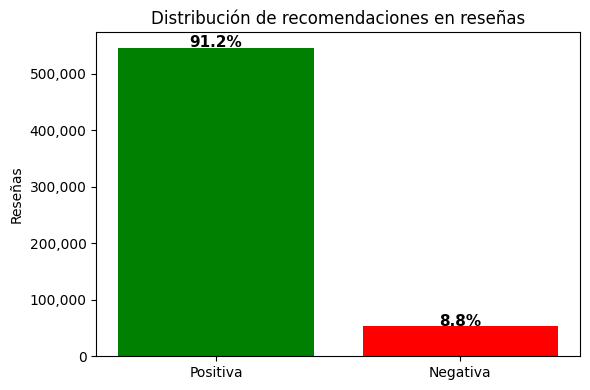

recomendado
Positiva    546371
Negativa     53040


In [9]:
conteo = df_carga['recomendado'].value_counts().rename({1: 'Positiva', 0: 'Negativa'})
pct    = (conteo / conteo.sum() * 100).round(1)

titulo='Distribución de recomendaciones en reseñas'

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(conteo.index, conteo.values, color=['green', 'red'])
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{p}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

print(conteo.to_string())

#parce que es mas gente la que recomienda juegos que la que no lo hace
#bsatante desvbalance

## palabras y letras por reseñas


In [10]:
df_carga['n_palabras'] = df_carga['resena_texto'].str.split().str.len()
df_carga['n_chars']    = df_carga['resena_texto'].str.len()

print('Palabras por reseña')
display(df_carga['n_palabras'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print('Caracteres por reseña')
display(df_carga['n_chars'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

Palabras por reseña


count   599,411.00
mean         41.82
std          95.40
min           0.00
25%           4.00
50%          13.00
75%          38.00
90%          98.00
95%         177.00
99%         465.00
max       2,034.00
Name: n_palabras, dtype: float64

Caracteres por reseña


count   599,411.00
mean        245.96
std         568.97
min           1.00
25%          20.00
50%          70.00
75%         224.00
90%         575.00
95%       1,030.00
99%       2,858.00
max       8,000.00
Name: n_chars, dtype: float64

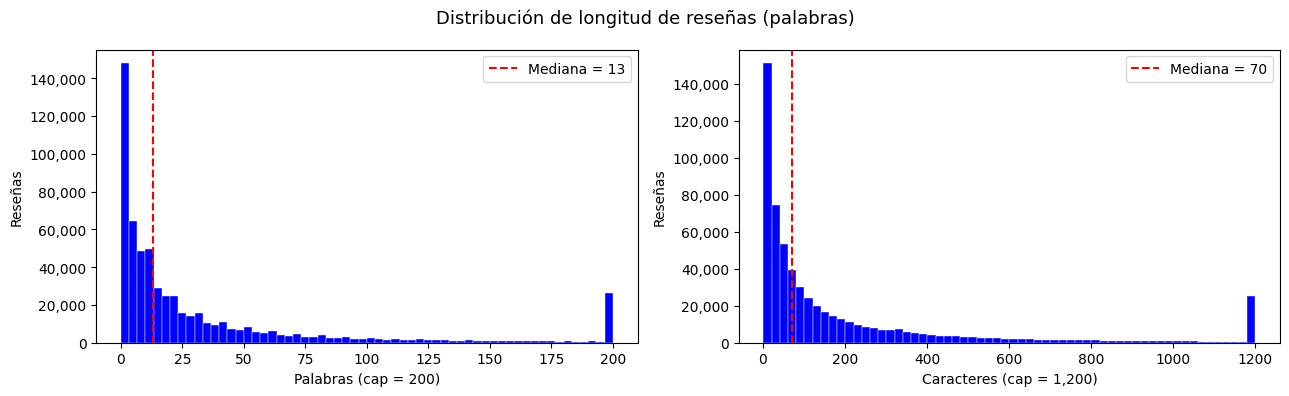

In [11]:
titulo = 'Distribución de longitud de reseñas (palabras)'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, cap in [
    (axes[0], 'n_palabras', 'Palabras', 200),
    (axes[1], 'n_chars',    'Caracteres', 1200),
]:
    data = df_carga[col].clip(upper=cap)
    ax.hist(data, bins=60, color='blue', edgecolor='white', linewidth=0.3)
    mediana = df_carga[col].median()
    ax.axvline(mediana, color='red', linestyle='--', label=f'Mediana = {mediana:.0f}')
    ax.set_xlabel(f'{label} (cap = {cap:,})')
    ax.set_ylabel('Reseñas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()

fig.suptitle(titulo, fontsize=13)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Votos utiles

In [12]:
display(df_carga['votos_utiles'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

count   599,411.00
mean          1.16
std           6.62
min           0.00
25%           0.00
50%           0.00
75%           1.00
90%           2.00
95%           5.00
99%          17.00
max       1,475.00
Name: votos_utiles, dtype: float64

In [13]:
cero = (df_carga['votos_utiles'] == 0).sum()
print(f'Con 0 votos útiles: {cero:,} ({cero/len(df_carga)*100:f}%)')

Con 0 votos útiles: 423,452 (70.644683%)


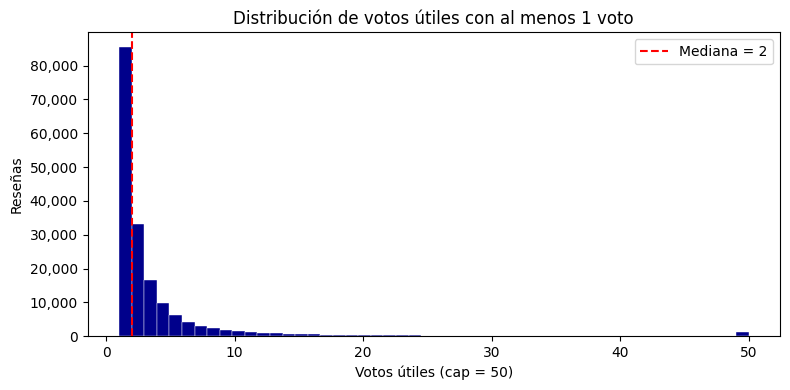

Reseñas con ≥1 voto: 175,959 (29.4%)
count   175,959.00
mean          3.96
std          11.75
min           1.00
50%           2.00
75%           3.00
90%           7.00
95%          13.00
99%          41.00
max       1,475.00


In [14]:
titulo = 'Distribución de votos útiles con al menos 1 voto'

data = df_carga[df_carga['votos_utiles'] > 0]['votos_utiles']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data.clip(upper=50), bins=50, color='darkblue', edgecolor='white', linewidth=0.3)
mediana = data.median()
ax.axvline(mediana, color='red', linestyle='--', label=f'Mediana = {mediana:.0f}')
ax.set_xlabel('Votos útiles (cap = 50)')
ax.set_ylabel('Reseñas')
ax.set_title(titulo)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Reseñas con ≥1 voto: {len(data):,} ({len(data)/len(df_carga)*100:.1f}%)')
print(data.describe(percentiles=[.5,.75,.90,.95,.99]).to_string())

## tiempo al reseñar

In [15]:
display(df_carga['horas_al_resenar'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

count   599,411.00
mean         65.48
std         311.62
min           0.02
25%           4.83
50%          13.33
75%          38.77
90%         107.98
95%         216.53
99%         999.95
max      22,181.62
Name: horas_al_resenar, dtype: float64

In [16]:
horas = df_carga['horas_al_resenar']
print(f'Reseñas con >10,000 horas: {(horas > 10000).sum():,}')
print(f'Reseñas con >1,000 horas: {(horas > 1000).sum():,}')
print(f'Reseñas con <1 hora:{(horas < 1).sum():,}')# gente que jugo un rato y solo opino

Reseñas con >10,000 horas: 79
Reseñas con >1,000 horas: 5,990
Reseñas con <1 hora:35,916


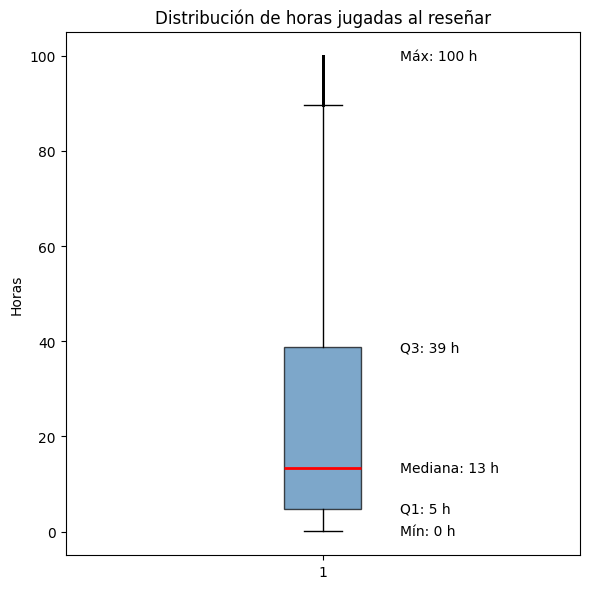

In [17]:
titulo = 'Distribución de horas jugadas al reseñar'
horas = df_carga['horas_al_resenar']
CAP = 100

data = horas.clip(upper=CAP)

fig, ax = plt.subplots(figsize=(6, 6))
bp = ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))
ax.set_title(titulo)
ax.set_ylabel('Horas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anotar valores clave
stats = {
    'Mín':    horas.min(),
    'Q1':     horas.quantile(0.25),
    'Mediana':horas.median(),
    'Q3':     horas.quantile(0.75),
    'Máx':    horas.clip(upper=CAP).max(),
}
for nombre, valor in stats.items():
    ax.annotate(f'{nombre}: {valor:.0f} h',
                xy=(1, min(valor, CAP)),
                xytext=(1.15, min(valor, CAP)),
                fontsize=10,
                va='center')

plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

##porcion de juegos comprados

In [18]:
display(df_carga['recibido_gratis'].value_counts())
display(df_carga['recibido_gratis'].value_counts(normalize=True).mul(100).round(1))

recibido_gratis
0    570685
1     28726
Name: count, dtype: int64

recibido_gratis
0   95.20
1    4.80
Name: proportion, dtype: float64

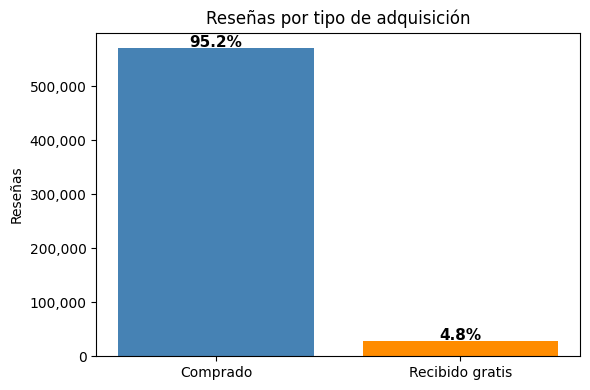

In [19]:
titulo = 'Reseñas por tipo de adquisición'

conteo = df_carga['recibido_gratis'].value_counts().rename({0: 'Comprado', 1: 'Recibido gratis'})
pct    = (conteo / conteo.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(conteo.index, conteo.values, color=['steelblue', 'darkorange'])
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{p}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## ver las fechas

In [20]:
df_carga['fecha'] = pd.to_datetime(df_carga['fecha_creacion_unix'], unit='s', errors='coerce')
print(f'Desde: {df_carga["fecha"].min()}')
print(f'Hasta: {df_carga["fecha"].max()}')
print(f'Nulos: {df_carga["fecha"].isna().sum()}')

Desde: 2010-10-30 05:58:25
Hasta: 2026-04-10 09:40:47
Nulos: 0


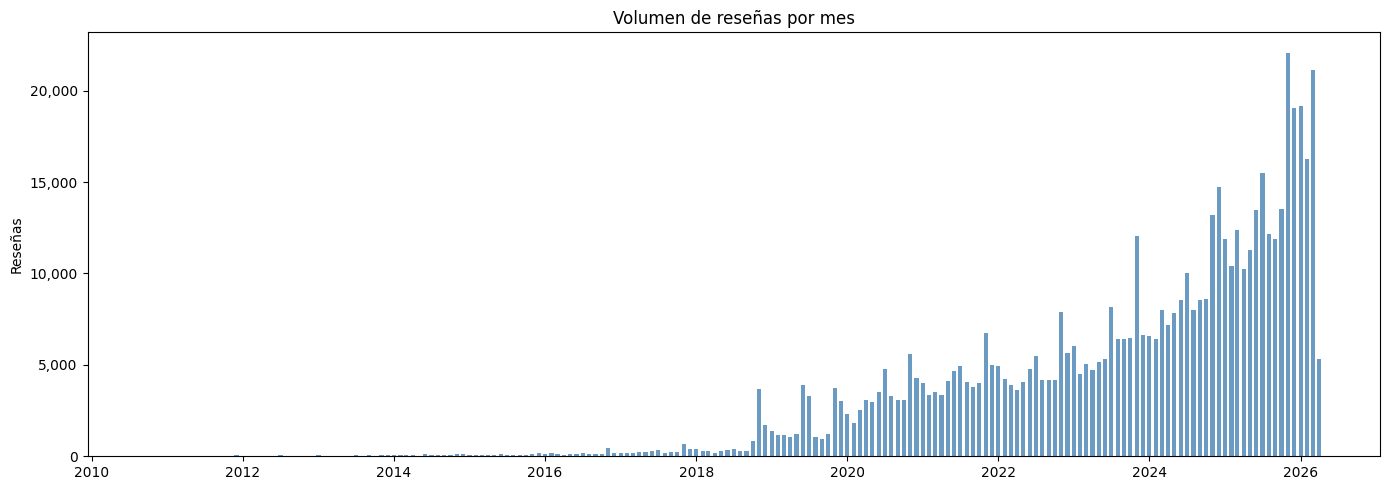

In [21]:
titulo = 'Volumen de reseñas por mes'

df_carga['mes'] = df_carga['fecha'].dt.to_period('M')
vol_mes = df_carga.groupby('mes').size().reset_index(name='total')
vol_mes['mes_dt'] = vol_mes['mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(vol_mes['mes_dt'], vol_mes['total'], width=20, color='steelblue', alpha=0.8)
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# es creciente las fechas hacia aca porque tome las primeras 1000 de cad juego y puede que muchso tengasn recientes y se acumularon a la dercha y 
# algunos cuantos ala querer alcanzar las 1000 se fueron hasta mas atras

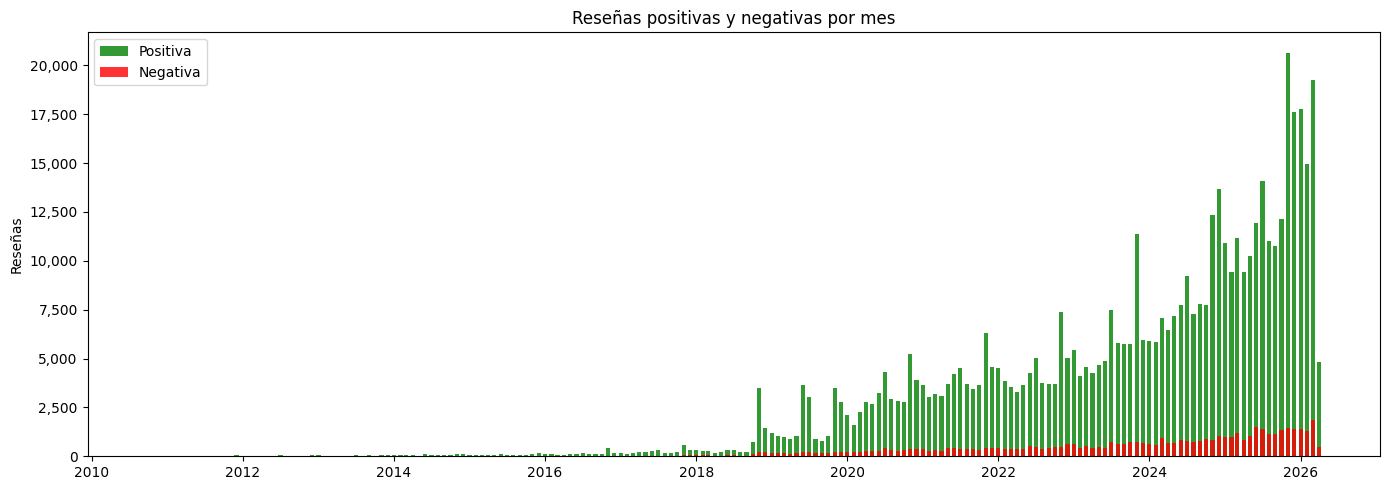

In [22]:
titulo = 'Reseñas positivas y negativas por mes'

vol_mes = (df_carga.groupby(['mes', 'recomendado'])
                   .size()
                   .reset_index(name='total'))
vol_mes['mes_dt'] = vol_mes['mes'].dt.to_timestamp()

pos = vol_mes[vol_mes['recomendado'] == 1]
neg = vol_mes[vol_mes['recomendado'] == 0]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pos['mes_dt'], pos['total'], width=20, color='green',  alpha=0.8, label='Positiva')
ax.bar(neg['mes_dt'], neg['total'], width=20, color='red',    alpha=0.8, label='Negativa')
ax.set_title(titulo)
ax.set_ylabel('Reseñas')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## horas jugdas y opiniones

C:\Users\ADRIA\AppData\Local\Temp\ipykernel_27476\3380437481.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, vert=True, patch_artist=True,


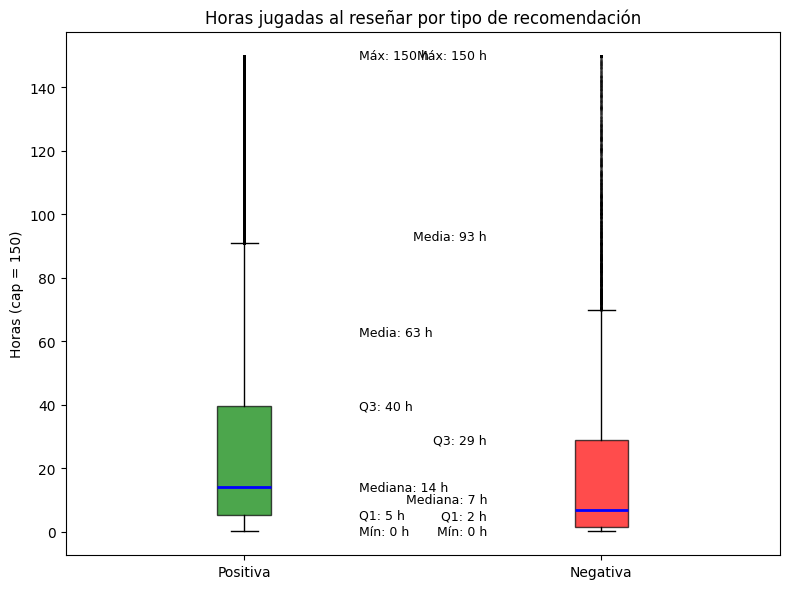

In [23]:
titulo = 'Horas jugadas al reseñar por tipo de recomendación'

horas = df_carga['horas_al_resenar']
CAP = 150

fig, ax = plt.subplots(figsize=(8, 6))
grupos = {
    'Positiva': horas[df_carga['recomendado'] == 1],
    'Negativa':  horas[df_carga['recomendado'] == 0],
}
data_plot = [d.clip(upper=CAP) for d in grupos.values()]

bp = ax.boxplot(data_plot, vert=True, patch_artist=True,
               labels=list(grupos.keys()),
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='blue', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))

bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

for i, (label, data) in enumerate(grupos.items(), start=1):
    stats = [
        ('Mín',max(data.min(), 0)),
        ('Q1', data.quantile(0.25)),
        ('Mediana', data.median()),
        ('Q3', data.quantile(0.75)),
        ('Media', data.mean()),
        ('Máx', min(data.max(), CAP)),
    ]
    offset_x = 0.32 if i == 1 else -0.32
    ha = 'left' if i == 1 else 'right'

    prev_y = -999
    for nombre, valor in stats:
        y = min(valor, CAP)
        # Si está muy cerca del anterior, empujar hacia arriba
        y_text = y if abs(y - prev_y) > 4 else prev_y + 5
        prev_y = y_text
        ax.annotate(f'{nombre}: {valor:.0f} h',
                    xy=(i, y),
                    xytext=(i + offset_x, y_text),
                    fontsize=9, va='center', ha=ha)

ax.set_title(titulo)
ax.set_ylabel(f'Horas (cap = {CAP})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## reseñas por juegos

In [24]:
por_juego = df_carga.groupby(['juego_id', 'titulo']).size().reset_index(name='total').sort_values('total', ascending=False)

print(f'Juegos con ≥1 reseña: {len(por_juego):,}')
print(f'Juegos con ≥10 reseñas: {(por_juego["total"] >= 10).sum():,}')
print(f'Juegos con ≥100 reseñas: {(por_juego["total"] >= 100).sum():,}')
print(f'Juegos con ≥1000 reseñas:{(por_juego["total"] >= 1000).sum():,}')
print()
print('Top 15 juegos por volumen:')
display(por_juego.head(15))

Juegos con ≥1 reseña: 5,825
Juegos con ≥10 reseñas: 3,918
Juegos con ≥100 reseñas: 1,243
Juegos con ≥1000 reseñas:51

Top 15 juegos por volumen:


,juego_id,titulo,total
172,226,PUBG: Battlegrounds,1002
428,581,Rust,1002
195,257,Rainbow Six Siege,1002
520,704,Black Myth: Wukong,1001
373,498,Helldivers 2,1001
28,36,Life is Strange,1000
663,920,The Last of Us Part II Remastered,1000
108,139,Cuphead,1000
927,1314,Duck Game,1000
21,27,Elden Ring,1000


In [25]:
display(por_juego.tail(15))
print()
print(por_juego['total'].describe(percentiles=[.25,.5,.75,.90,.95]).to_string())

,juego_id,titulo,total
5420,9398,Spirittea,1
2949,4803,Cossacks II: Napoleonic Wars,1
2946,4792,Leisure Suit Larry: Reloaded,1
2944,4783,De Blob 2,1
5453,9445,BloodRayne Betrayal: Fresh Bites,1
5452,9444,Minds Beneath Us,1
2880,4682,Tchia,1
5435,9420,100 Hidden Dogs,1
2906,4725,Touhou Kaeizuka: Phantasmagoria of Flower View,1
2922,4749,The Solus Project,1



count   5,825.00
mean      102.90
std       212.72
min         1.00
25%         6.00
50%        21.00
75%        78.00
90%       280.60
95%       618.00
max     1,002.00


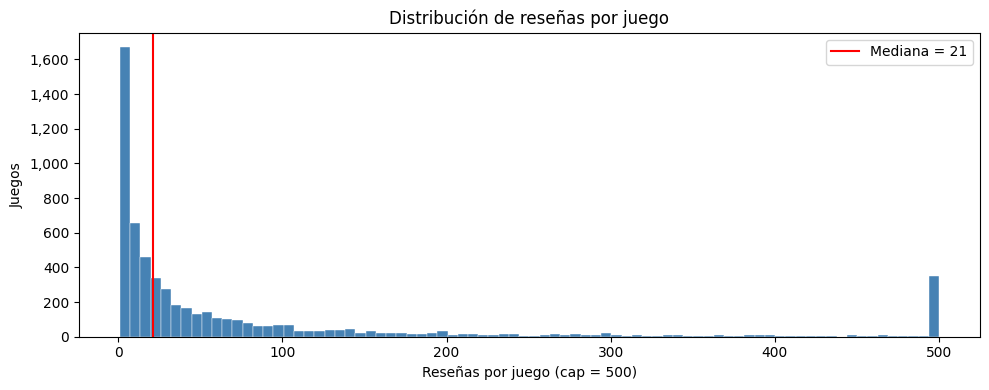

In [26]:
titulo = 'Distribución de reseñas por juego'

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(por_juego['total'].clip(upper=500), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
mediana = por_juego['total'].median()
ax.axvline(mediana, color='red', label=f'Mediana = {mediana:.0f}')
ax.set_title(titulo)
ax.set_xlabel('Reseñas por juego (cap = 500)')
ax.set_ylabel('Juegos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Horas jugadas vs votos útiles

In [27]:
display(df_carga[['horas_al_resenar', 'votos_utiles']].corr())
# al menos linelemente no veo correlacion entre las reviws utiles y las horas al reseñar

,horas_al_resenar,votos_utiles
horas_al_resenar,1.00,0.01
votos_utiles,0.01,1.00


## Longitud del texto vs votos útiles

In [28]:
display(df_carga[['n_palabras', 'votos_utiles']].corr())
# ya ahy por lo menos algo de realcion el la logitud de texto y utilidad, pude que la escriobir mas puede que se diga algo importante
# pero es muy bajo

,n_palabras,votos_utiles
n_palabras,1.00,0.13
votos_utiles,0.13,1.00


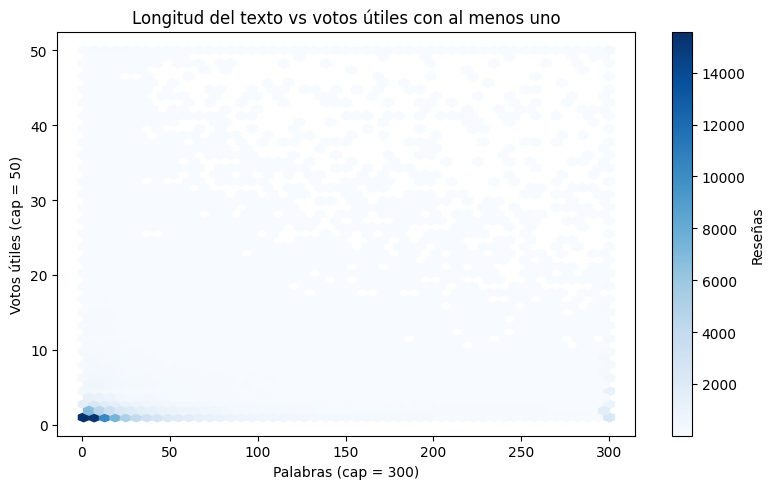

In [29]:
titulo = 'Longitud del texto vs votos útiles con al menos uno'

df_filtrado = df_carga[(df_carga['votos_utiles'] >= 1) & (df_carga['n_palabras'] >= 1)]

fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(
    df_filtrado['n_palabras'].clip(upper=300),
    df_filtrado['votos_utiles'].clip(upper=50),
    gridsize=50, cmap='Blues', mincnt=1
)
plt.colorbar(hb, ax=ax, label='Reseñas')
ax.set_title(titulo)
ax.set_xlabel('Palabras (cap = 300)')
ax.set_ylabel('Votos útiles (cap = 50)')
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Longitud del texto vs recomendación

In [30]:
display(df_carga.groupby('recomendado')['n_palabras'].describe(percentiles=[.25,.5,.75,.90,.95]))
# parece que las resenas que no recomindan tienden a escribir mas, tienen mas que decir

,count,mean,std,min,25%,50%,75%,90%,95%,max
recomendado,,,,,,,,,,
0,"53,040.00",64.35,118.03,0.00,9.00,26.00,68.00,154.00,252.00,"1,523.00"
1,"546,371.00",39.64,92.61,0.00,3.00,12.00,35.00,92.00,168.00,"2,034.00"


C:\Users\ADRIA\AppData\Local\Temp\ipykernel_27476\3350676171.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, vert=True, patch_artist=True,


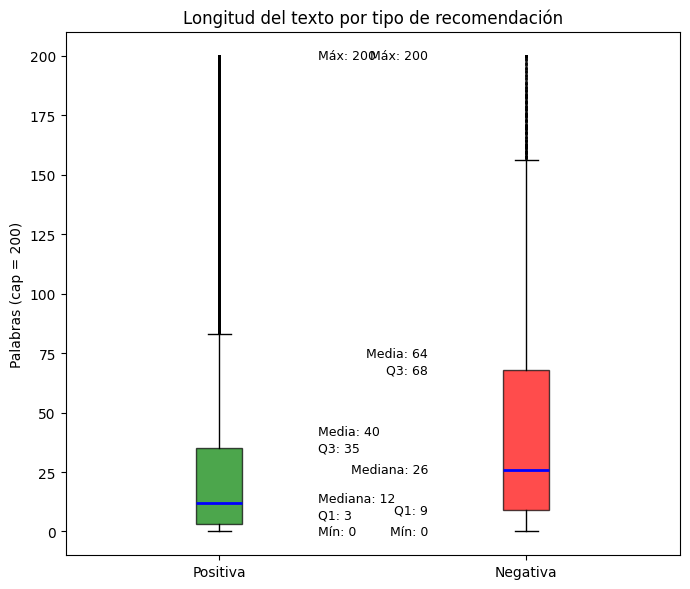

In [31]:
titulo = 'Longitud del texto por tipo de recomendación'

CAP = 200
fig, ax = plt.subplots(figsize=(7, 6))

grupos = {
    'Positiva': df_carga[df_carga['recomendado'] == 1]['n_palabras'],
    'Negativa':  df_carga[df_carga['recomendado'] == 0]['n_palabras'],
}
data_plot = [d.clip(upper=CAP) for d in grupos.values()]

bp = ax.boxplot(data_plot, vert=True, patch_artist=True,
               labels=list(grupos.keys()),
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='blue', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))

bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

for i, (label, data) in enumerate(grupos.items(), start=1):
    stats = [
        ('Mín', max(data.min(), 0)),
        ('Q1', data.quantile(0.25)),
        ('Mediana', data.median()),
        ('Q3', data.quantile(0.75)),
        ('Media', data.mean()),
        ('Máx', min(data.max(), CAP)),
    ]
    offset_x = 0.32 if i == 1 else -0.32
    ha = 'left' if i == 1 else 'right'
    prev_y = -999
    for nombre, valor in stats:
        y = min(valor, CAP)
        y_text = y if abs(y - prev_y) > 6 else prev_y + 7
        prev_y = y_text
        ax.annotate(f'{nombre}: {valor:.0f}',
                    xy=(i, y), xytext=(i + offset_x, y_text),
                    fontsize=9, va='center', ha=ha)

ax.set_title(titulo)
ax.set_ylabel(f'Palabras (cap = {CAP})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Recibido gratis vs recomendación

In [32]:
display(df_carga.groupby('recibido_gratis')['recomendado'].agg(['mean','count']).rename(columns={'mean':'pct_positiva','count':'total'}))

,pct_positiva,total
recibido_gratis,,
0,0.91,570685
1,0.86,28726


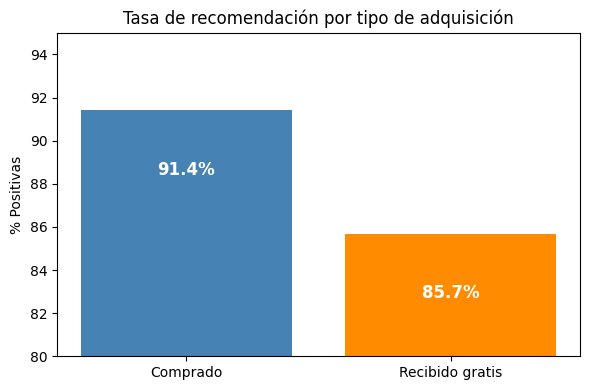

In [33]:
titulo = 'Tasa de recomendación por tipo de adquisición'

data = df_carga.groupby('recibido_gratis')['recomendado'].mean() * 100
data.index = ['Comprado', 'Recibido gratis']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(data.index, data.values, color=['steelblue', 'darkorange'])
for bar, v in zip(bars, data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
            f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold', color='white')
ax.set_title(titulo)
ax.set_ylabel('% Positivas')
ax.set_ylim(80, 95)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# recibir un juego gratis no exime que tenga mas recomendacion, de ehco tien menos, esto pude ser poque realmente ningun juego es gratis y 
# esos puden tener metodos de compra que pueden provocar menos recomendaciones

##  Longitud del texto vs horas jugadas

In [34]:
display(df_carga[['n_palabras', 'horas_al_resenar']].corr())
# jugar más horas no hace que escribas más, al menos no hay relacion lineal

,n_palabras,horas_al_resenar
n_palabras,1.00,0.00
horas_al_resenar,0.00,1.00


## Votos útiles vs recomendación

In [35]:
display(df_carga.groupby('recomendado')['votos_utiles'].describe(percentiles=[.25,.5,.75,.90,.95]))
#las negativas reciben más del doble de votos útiles en media y del cuartil hacia arriba

,count,mean,std,min,25%,50%,75%,90%,95%,max
recomendado,,,,,,,,,,
0,"53,040.00",2.44,13.62,0.00,0.00,0.00,2.00,5.00,9.00,"1,475.00"
1,"546,371.00",1.04,5.46,0.00,0.00,0.00,1.00,2.00,4.00,806.00


C:\Users\ADRIA\AppData\Local\Temp\ipykernel_27476\2414872990.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, vert=True, patch_artist=True,


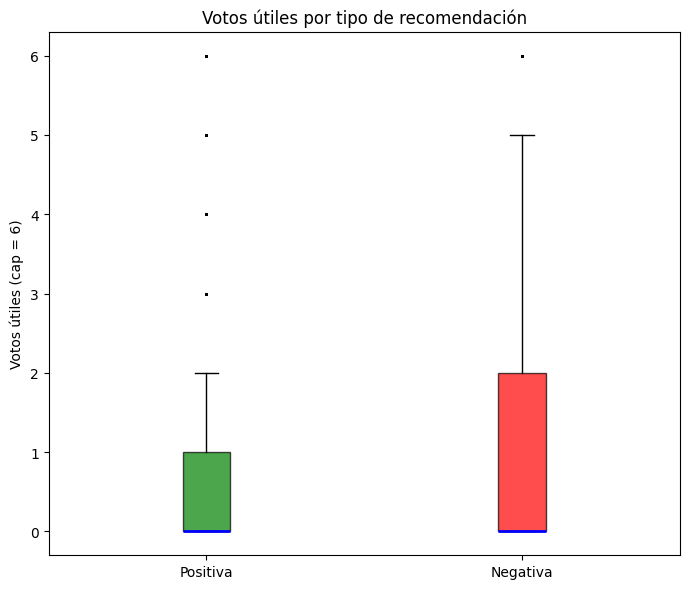

Positiva: mín=0  Q1=0  mediana=0  Q3=1  media=1.0  máx=806
Negativa: mín=0  Q1=0  mediana=0  Q3=2  media=2.4  máx=1475


In [36]:
titulo = 'Votos útiles por tipo de recomendación'

CAP = 6
fig, ax = plt.subplots(figsize=(7, 6))

grupos = {
    'Positiva': df_carga[df_carga['recomendado'] == 1]['votos_utiles'],
    'Negativa':  df_carga[df_carga['recomendado'] == 0]['votos_utiles'],
}
data_plot = [d.clip(upper=CAP) for d in grupos.values()]

bp = ax.boxplot(data_plot, vert=True, patch_artist=True,
               labels=list(grupos.keys()),
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='blue', linewidth=2),
               flierprops=dict(marker='.', alpha=0.1, markersize=2))

bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

ax.set_title(titulo)
ax.set_ylabel(f'Votos útiles (cap = {CAP})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticos por separado
for label, data in grupos.items():
    print(f'{label}: mín={data.min():.0f}  Q1={data.quantile(.25):.0f}  mediana={data.median():.0f}  Q3={data.quantile(.75):.0f}  media={data.mean():.1f}  máx={data.max():.0f}')

## Año de la reseña vs longitud

In [37]:
print('')
display(df_carga.groupby('anio')['n_palabras'].describe(percentiles=[.25,.5,.75]).round(1))

,count,mean,std,min,25%,50%,75%,max
anio,,,,,,,,
2010,48.00,40.10,34.90,2.00,15.50,27.00,58.20,160.00
2011,202.00,36.60,43.50,1.00,11.00,21.00,47.00,307.00
2012,281.00,45.10,66.90,1.00,10.00,23.00,54.00,562.00
2013,499.00,42.80,68.10,0.00,8.00,19.00,51.50,773.00
2014,887.00,92.00,152.20,1.00,13.50,39.00,104.50,"1,307.00"
2015,"1,122.00",108.00,184.40,0.00,15.00,43.00,111.00,"1,322.00"
2016,"1,905.00",99.00,176.00,1.00,13.00,37.00,102.00,"1,477.00"
2017,"3,284.00",89.70,146.10,1.00,14.00,39.00,103.20,"1,373.00"
2018,"8,995.00",67.80,126.60,0.00,9.00,26.00,69.00,"1,491.00"


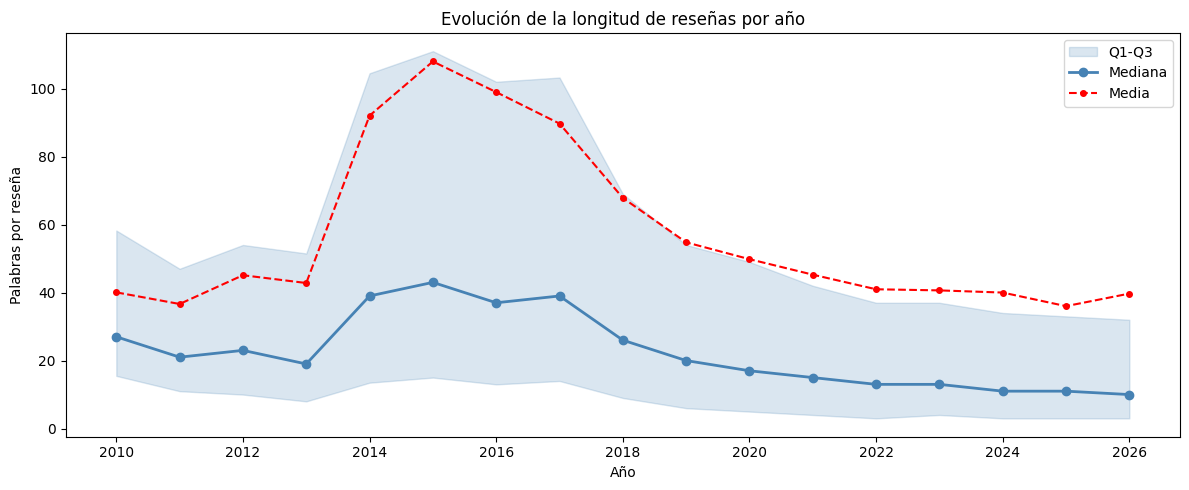

In [38]:
titulo = 'Evolución de la longitud de reseñas por año'

resumen_anio = df_carga.groupby('anio')['n_palabras'].agg(
    mediana='median', media='mean', q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(resumen_anio['anio'], resumen_anio['q1'], resumen_anio['q3'], alpha=0.2, color='steelblue', label='Q1-Q3')
ax.plot(resumen_anio['anio'], resumen_anio['mediana'], color='steelblue', linewidth=2, marker='o', label='Mediana')
ax.plot(resumen_anio['anio'], resumen_anio['media'],   color='red',      linewidth=1.5, linestyle='--', marker='o', markersize=4, label='Media')
ax.set_title(titulo)
ax.set_ylabel('Palabras por reseña')
ax.set_xlabel('Año')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Reseñas por juego vs % positivas

In [39]:
por_juego = df_carga.groupby(['juego_id', 'titulo']).agg(
    total = ('resena_id', 'count'),
    pct_pos= ('recomendado', 'mean')
).reset_index().sort_values('total', ascending=False)

display(por_juego[['total', 'pct_pos']].corr())
#Los juegos con más reseñas no necesariamente tienen mejor o peor rating.

,total,pct_pos
total,1.00,0.08
pct_pos,0.08,1.00


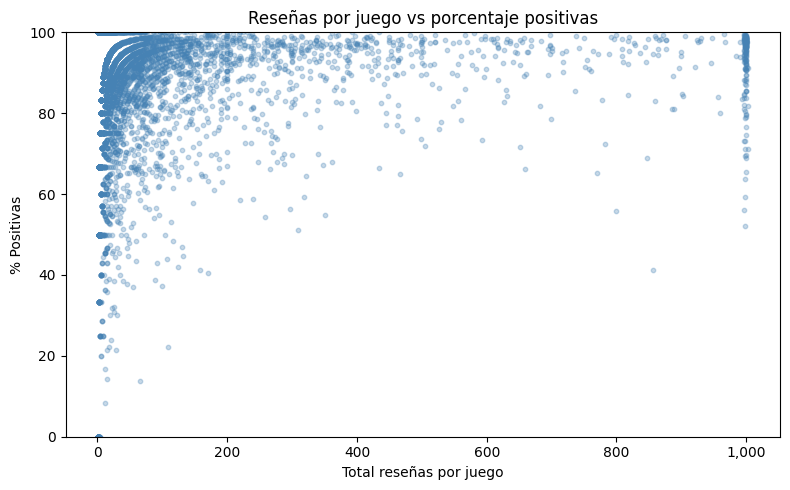

In [40]:
titulo = 'Reseñas por juego vs porcentaje positivas'

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(por_juego['total'], por_juego['pct_pos'] * 100,
           alpha=0.3, s=10, color='steelblue')
ax.set_title(titulo)
ax.set_xlabel('Total reseñas por juego')
ax.set_ylabel('% Positivas')
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()
#Los juegos con pocas reseñas tienen varianza enorme
# pueden estar en cualquier punto entre 0% y 100% porque con 1-5 reseñas cualquier cosa es posible
# Conforme aumentan las reseñas la varianza se comprime y converge hacia el 80-90% que es el promedio general.

# notas de EDA

- parce que es mas gente la que recomienda juegos que la que no lo hace
- bsatante desvbalance
- la mitad de las reseñas son muy cortas con 13 palabras
- El 25% tiene 4 palabras o menos
- El 99% llega a 465 palabras pero el máximo es 2,034 hay gente que escribe ensayos o estan molesatando
- Habra que revisar como son las reseñas de 13 palabras y de 4 palabras
- de las resñeas  423,452 (70.644683%) no se consideran utiles, y los que lo hacen tiene la mitad es 2, esta variable no me parece que aportara nada debido a su baja cardinalidad y sesgo a valores pequeños
- hay algunos que aprce que llevan jundo 22,181.62 horas, como 2.5 años, es posoble pero abra que ver esos datos ouliers, hay otros de 0. horas que habra que ver que opinan
-al menos la mediana se ve bien y el primer cuartil se tiene 5 horas, ni tan bueno ni tan malo
-el 95 esta dominado por comprar reales, eso es bueno
-es creciente las fechas hacia aca porque tome las primeras 1000 de cad juego y puede que muchso tengasn recientes y se acumularon a la dercha y algunos cuantos ala querer alcanzar las 1000 se fueron hasta mas atras
- no veo algo relvante en la cantidad de reseñas positivas y negeativas
- los que recomemiendan menos el juego tienen una mediana de menos horas de juego, lo dejan antes u odian por odiar. pero lo curioso es que la emdia de negativas es mas alta por los ouliers, ay gente que jugó muchísimo y aun así no recomienda, probablemente frustración acumulada o cambios en el juego con el tiempo.
- muchos juegos tiene muy pocas resenas, puede que sirvan apra anzalizar el apnorma general pero no el juego en si, esos con mcuhas reseñas dominaran al juego
- al menos linealmente no veo correlacion entre las reviws utiles y las horas al reseñar
- ya ahy por lo menos algo de realcion el la logitud de texto y utilidad, pude que la escriobir mas puede que se diga algo importante pero es muy bajo
- parece que las reseñas que no recomindan tienden a escribir mas, mas o menos el doble, tienen mas que decir al rspecto del juego
- recibir un juego gratis no exime que tenga mas recomendacion, de ehco tien menos, esto pude ser poque realmente ningun juego es gratis y esos puden tener metodos de compra que pueden provocar menos recomendaciones
- jugar más horas no hace que escribas más
- las negativas reciben más del doble de votos útiles en media y del tercer cuartil hacia arriba. Cuando alguien escribe una reseña negativa bien argumentada, la comunidad la encuentra más útil.
- Los juegos con más reseñas no necesariamente tienen mejor o peor rating.
- Los juegos con pocas reseñas tienen varianza enorme pueden estar en cualquier punto entre 0% y 100% porque con 1-5 reseñas cualquier cosa es posible
- Conforme aumentan las reseñas la varianza se comprime y converge hacia el 80-90% que es el promedio general.
-
-
-
-
-
-
-


# Limpieza

In [41]:
df_limpio = df_carga.copy()

In [42]:
df_limpio['resena_limpia']=df_limpio['resena_texto']

In [43]:
df_limpio['resena_limpia'].sample()

546455    EXCELENTE JUEGO
Name: resena_limpia, dtype: str

## normalizar palabras malsoantes, expresione spositvas fuertes y etc

Con bert no usaremos este campo

## limpiar por densidad de caracteres asccii

In [44]:
CHARS_ARTE = re.compile(r'[\u2580-\u259F\u25A0-\u25FF\u2800-\u28FF\u2600-\u26FF\uFF00-\uFFEF\u3000-\u30FF\u4E00-\u9FFF\u2700-\u27BF]')

def eliminar_lineas_ascii_art(texto):
    lineas = texto.split('\n')
    limpias = []
    for linea in lineas:
        linea_strip = linea.strip()
        if not linea_strip:
            continue
        linea_sin_arte = CHARS_ARTE.sub('', linea_strip).strip()
        total = len(linea_strip)
        reales = len(re.findall(r'[a-záéíóúüñA-ZÁÉÍÓÚÜÑ0-9]', linea_sin_arte))
        ratio = reales / total
        if ratio < 0.3:
            fragmentos = re.findall(r'[a-záéíóúüñA-ZÁÉÍÓÚÜÑ][a-záéíóúüñA-ZÁÉÍÓÚÜÑ0-9\s,\.!?¿¡\'\"]{4,}', linea_strip)
            if fragmentos:
                limpias.extend(f.strip() for f in fragmentos)
            continue
        limpias.append(linea_sin_arte if linea_sin_arte else linea_strip)
    return ' '.join(limpias)

In [45]:
PATRON_ASCII_ART = re.compile(r'[⠀-⣿／＞＿￣ω]')

muestra_ascii = df_carga[
    df_carga['resena_texto'].apply(lambda x: bool(PATRON_ASCII_ART.search(str(x))))
].sample(10)

for texto in muestra_ascii['resena_texto']:
    print('ORIGINAL:')
    print(texto)
    print('RESULTADO:')
    print(eliminar_lineas_ascii_art(texto))
    print("_"*200)

ORIGINAL:
⠄⠄⠄⢀⠄⠄⢀⠠⢂⣵⣾⠃⠄⠄⠄⠄⠄⠄⠄⠄⠄⢀⠂⠄
⡀⠄⠈⢀⡠⡌⣴⣾⣿⡿⠃⠄⠄⠄⠄⠄⠄⠄⠄⢀⣤⡎⠄⠄
⠁⠄⢀⣠⣤⣤⣤⣈⠈⠄⠄⠄⠄⠄⠄⠄⠠⢊⢄⣽⡟⠄⠄⠄
⠆⢰⠋⠄⠄⠄⠙⢿⣿⣦⡄⠄⣣⣤⣶⣯⣤⡔⣿⡟⡀⠄⠄⠄
⣷⣷⣀⢔⠄⠄⠤⣼⣿⣿⣿⢀⢩⣽⣿⣿⣿⣿⣟⡄⠄⠄⠄⠄
⣿⣿⣿⣷⣦⣲⣾⣿⣿⣿⡿⢸⣾⣿⣿⣿⣿⣿⣿⣿⣷⣶⣄⣀
⣿⣿⣿⣿⣿⣿⣾⣿⣻⣿⣧⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠛⣋⣍⡈⠙
⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠁⡀⣀⣿⡇⣀
⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⢀⣠⣾⣿⡴⠋
RESULTADO:

________________________________________________________________________________________________________________________________________________________________________________________________________
ORIGINAL:
+20 SOCIAL CREDIT ( ͡° ͜ʖ ͡°)

⣿⣿⣿⣿⣿⠟⠋⠄⠄⠄⠄⠄⠄⠄⢁⠈⢻⢿⣿⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⠃⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠈⡀⠭⢿⣿⣿⣿⣿
⣿⣿⣿⣿⡟⠄⢀⣾⣿⣿⣿⣷⣶⣿⣷⣶⣶⡆⠄⠄⠄⣿⣿⣿⣿
⣿⣿⣿⣿⡇⢀⣼⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣧⠄⠄⢸⣿⣿⣿⣿
⣿⣿⣿⣿⣇⣼⣿⣿⠿⠶⠙⣿⡟⠡⣴⣿⣽⣿⣧⠄⢸⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣾⣿⣿⣟⣭⣾⣿⣷⣶⣶⣴⣶⣿⣿⢄⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣿⣿⣿⡟⣩⣿⣿⣿⡏⢻⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣿⣹⡋⠘⠷⣦⣀⣠⡶⠁⠈⠁⠄⣿⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣿⣍⠃⣴⣶⡔⠒⠄⣠⢀⠄⠄⠄⡨⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣿⣿⣦⡘⠿⣷⣿⠿⠟⠃⠄⠄⣠⡇⠈⠻⣿⣿⣿⣿
⣿⣿⣿⣿⡿⠟⠋⢁⣷⣠⠄⠄⠄⠄⣀⣠⣾⡟⠄⠄⠄⠄⠉⠙⠻
⡿⠟⠋⠁⠄⠄⠄⢸⣿⣿⡯⢓⣴⣾⣿⣿⡟⠄⠄⠄⠄⠄⠄⠄⠄
⠄⠄⠄⠄⠄⠄⠄⣿⡟⣷⠄⠹⣿⣿⣿⡿⠁⠄⠄⠄⠄⠄⠄⠄⠄

+1 WAIFU

⣿⣿⣿⣿⠛⠛⠉⠄⠁⠄⠄⠉⠛⢿⣿⣿⣿⣿⣿⣿⣿
⣿⣿⡟⠁⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⣿⣿⣿⣿⣿⣿⣿
⣿⣿⡇⠄⠄⠄⠐⠄⠄⠄⠄⠄⠄⠄⠠⣿⣿⣿⣿⣿⣿
⣿⣿⡇⠄⢀⡀⠠⠃⡐⡀⠠⣶⠄⠄⢀⣿⣿⣿⣿⣿⣿
⣿⣿⣶⠄⠰⣤⣕⣿⣾⡇⠄⢛⠃⠄⢈⣿⣿⣿⣿⣿⣿
⣿⣿⣿⡇⢀⣻⠟⣻⣿⡇⠄⠧⠄⢀⣾⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣟⢸

In [46]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(eliminar_lineas_ascii_art)

## Limpiar el ruido

In [47]:
PATRONES_RUIDO = [
    (r'\[\/?\w+\]', ' '),
    (r'<[^>]+>', ' '),
    (r'&\w+;', ' '),

    (r'http\S+|www\.\S+', ' '),

    (r'[\u2580-\u259F\u25A0-\u25FF\u2600-\u26FF\u2700-\u27BF]', ' '),
    (r'[\u2300-\u23FF]', ' '),
    (r'[\u2100-\u214F]', ' '),
    (r'[★☆♥♦♠♣♤♧♡]', ' '),

    (r'\.{2,}', '...'),
    (r'!{2,}', '!'),
    (r'¡{2,}', '¡'),

    (r'\?{2,}', '?'),
    (r'\¿{2,}', '¿'),
    (r'-{3,}', ' '),
    
    (r'={3,}', ' '),
    (r'_{3,}', ' '),
    (r'\*{2,}', ' '),
    (r'#{2,}', ' '),

    (r'\n+', ' '),
    (r'\t+', ' '),
    (r'\r+', ' '),

    (r'[\u2800-\u28FF]+', ' '),
    (r',{2,}', ','),
    (r';{2,}', ';'),

    (r'[\uFF00-\uFFEF]', ' '),
    (r'[\u3000-\u303F]', ' '),
    (r'[\u3040-\u309F]', ' '),
    (r'[\u30A0-\u30FF]', ' '),
    (r'[\u4E00-\u9FFF]', ' '),
    ]

In [48]:
def eliminar_ruido(texto):
    for patron, reemplazo in PATRONES_RUIDO:
        texto = re.sub(patron, reemplazo, texto)
    return texto

In [49]:
def probar_limpieza(fn, df, columna='resena_texto', n=1):
    for patron, _ in PATRONES_RUIDO:
        try:
            patron_compilado = re.compile(patron)
            muestra = df[df[columna].apply(lambda x: bool(patron_compilado.search(x)))]
        except re.error:
            print(f'PATRON INVÁLIDO: {patron}\n')
            continue
        if muestra.empty:
            print(f'PATRON: {patron} — sin coincidencias\n')
            continue
        muestras = muestra.sample(min(n, len(muestra)))[columna].values
        print(f'PATRON: {patron}')
        for texto in muestras:
            print(f'  ORIGINAL:  {texto[:200]}')
            print(f'  RESULTADO: {fn(texto)[:200]}')
            print("--"*20)
        print()

In [50]:
probar_limpieza(eliminar_ruido,df_limpio,"resena_texto",2)

PATRON: \[\/?\w+\]
  ORIGINAL:  [h1]🎮 Reseña de Brutal Legend[/h1]

[h2]Resumen del Juego[/h2]
Brutal Legend es esa mezcla rarísima (y valiente) de [b]Acción + Aventura + Estrategia[/b] que suena como “¿quién dejó a un guitarrista d
  RESULTADO:  🎮 Reseña de Brutal Legend   Resumen del Juego  Brutal Legend es esa mezcla rarísima (y valiente) de  Acción + Aventura + Estrategia  que suena como “¿quién dejó a un guitarrista diseñar un juego?”… y
----------------------------------------
  ORIGINAL:  [h1][b]Esta mono[/b][/h1]
Pero no tan bueno como para jugarlo 400 horas.

[h2]Jugabilidad: [b]7.5/10[/b][/h2]
El mejor tower defense porque solo compite contra pvz y juegos de roblox. Es buena y tiene
  RESULTADO:   Esta mono   Pero no tan bueno como para jugarlo 400 horas.  Jugabilidad:  7.5/10   El mejor tower defense porque solo compite contra pvz y juegos de roblox. Es buena y tienes que pensar, pero es cie
----------------------------------------

PATRON: <[^>]+>
  ORIGINAL:  [h1] Le Falta

In [51]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(eliminar_ruido)

## nueva normlizacion

In [52]:
NORMALIZACION_DE_intesidad = {

    r'\bmierd[ao]s?\b': 'mierda',
    r'\bm[ie3]rd[ao]s?\b': 'mierda',
    r'\bmrd\b': 'mierda',

    r'\bchingad[ao]s?\b': 'chingada',
    r'\bpinch[eao]s?\b': 'pinche',

    r'\bporquer[ií]as?\b': 'porqueria',

    r'\bpdo\b': 'pedo',

    r'\bgüev[oó]n\b': 'guevon',
    r'\bhuev[oó]n\b': 'guevon',
    r'\bweón\b':'guevon',

    r'\bculiao\b':'culiao',
    r'\bculos?\b':'culo',

    r'\bimbécil\b':'imbecil',

    r'\bv[3e]rg[4a][4a]?\b':'verga',
    r'\bc[4a]g[4a]d[4a]\b':'cagada',
    r'\bput[#@4a]\b': 'puta',
    r'\bp[#0o$]to\b': 'puto',
    r'\bF[#u]CK YOU\b':'jodete',
    r'\bj[0o]der\b': 'joder',

    r'\bjuegazo\b':'buen juego',
    r'\bperfectazo\b':'perfeycto',
    r'\bpeak\b': 'expresion_positiva_fuerte',
    r'\bultraepicardo\b': 'bultra epico',
    r'\bweno\b': 'bueno',
    r'\bgud\b': 'bueno',
    r'\bptmr?\b':'puta madre',

    r'\b(ja|je|ji|js|ha|he|hi){2,}\b':'expresion_risa',
    r'(ja|je|ji|js|ha|he|hi){4,}': 'expresion_risa',
    r'\bxd+\b': 'risa',
    r'\blmao\b': 'risa',
    r'\blol\b': 'risa',
    r'\bomg\b':'sorprendido',
    r'\bwtf\b': '¿que paso?',
    r'z{3,}':'aburrido',
    r'\balv\b': 'a la verga',
    r'\bASMR\b': 'Respuesta Sensorial Meridiana Autónoma',

    r'\buwu\b': 'ternura',
    r'\bhijo\s+de\s+fruta\b':  'hijo de puta',
    r'\blpm\b':  'la puta madre',
    r'.-.':  'decepción',
    r':"\(': 'tristeza',
    r':0':  'asombro',
    r':\)': 'expresion feliz',
    r':\(': 'expresion triste',
    r':D':  'expresion feliz',
    r'xD':  'expresion risa',
    r';\)': 'expresion picaro',
    r':P': 'expresion burla',
    r':/':'expresion duda',
    r'>:<': 'expresion enojo',
    r'T_T': 'expresion triste',
    r':\)': 'expresion feliz',
    r':\|': 'expresion neutral' 
     
}

In [53]:
def normalizar_intensidad(texto):
    for patron, reemplazo in NORMALIZACION_DE_intesidad.items():
        texto = re.sub(patron, reemplazo, texto, flags=re.IGNORECASE)
    return texto

In [54]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(normalizar_intensidad)

In [55]:
df_limpio[['resena_texto','resena_limpia']].head(10)

,resena_texto,resena_limpia
0,esta divertido,esta divertido
1,"Si te odias, este juego es para vos🤙🏽","Si te odias, este juego es para vos🤙🏽"
2,que buen juego que es\n,que buen juego que es
3,Todos mis hijos,Todos mis hijos
4,solo quiero el logro por la 1°ra reseña. muchas gracias!!!! \n,solo quiero el logro por la 1°ra reseña. muchas gracias!
5,"Este juego me ha hecho darme cuenta que no sirvo para nada, mucho menos matar gente inocente. posdata: la actualizacion de los cartuchos es una verga","Este juego me ha hecho darme cuenta que no sirvo para nada, mucho menos matar gente inocente. posdata: la actualizacion de los cartuchos es una verga"
6,prohiban brasil \n,prohiban brasil
7,God,God
8,"Lo probé porque vengo de Valorant, era main Sage pero ya no me gusta más ese juego.\r\nQuise probar algo del mismo género y me gustó mucho, apoyo bastante, así que si quieren jugar tienen una Sniper disponible :D","Lo probé porque vengo de Valorant, era main Sage pero ya no me gusta más ese juego. Quise probar algo del mismo género y me gustó mucho, apoyo bastante, así que si quieren jugar tienen una Sniper disponible expresion feliz"
9,.,


## reducir la palabra que tengan muchos espacios

In [56]:
def colapsar_letras_espaciadas(texto):
    return re.sub(r'\b([a-záéíóúüñ] ){2,}[a-záéíóúüñ]\b', 
                  lambda m: m.group(0).replace(' ', ''), 
                  texto)

In [57]:
muestra_espaciadas = df_limpio[
    df_limpio['resena_limpia'].str.contains(r'\b([a-záéíóúüñ] ){2,}[a-záéíóúüñ]\b', regex=True)
].sample(10)

pruebas = muestra_espaciadas['resena_limpia'].tolist()

for texto in pruebas:
    print(f'ORIGINAL:{texto[:200]}')
    print(f'RESULTADO: {colapsar_letras_espaciadas(texto)[:200]}')
    print()

ORIGINAL:La segunda parte de The Last of Us es la prueba viviente de que los juegos pueden ser algo más que entretenimiento. La segunda parte de The Last of Us trata de la venganza, el remordimiento y el perdó
RESULTADO: La segunda parte de The Last of Us es la prueba viviente de que los juegos pueden ser algo más que entretenimiento. La segunda parte de The Last of Us trata de la venganza, el remordimiento y el perdó

ORIGINAL:Me encanta este juego, es como hacer los mandados en tu día a día pero pudiendo "Echar un Cloro" en donde se te cante.
RESULTADO: Me encanta este juego, es como hacer los mandados en tu día a día pero pudiendo "Echar un Cloro" en donde se te cante.

ORIGINAL:y e s .
RESULTADO: yes .

ORIGINAL:Llevo jugando un tiempo, actualizaré mi reseña cuando lleve más horas de juego. Lo malodecepciónLos personajes de apoyo casi no hacen daño y a veces ni para distraer a los enemigos sirvendecepciónSólo
RESULTADO: Llevo jugando un tiempo, actualizaré mi reseña cuando lleve má

C:\Users\ADRIA\AppData\Local\Temp\ipykernel_27476\307162077.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_limpio['resena_limpia'].str.contains(r'\b([a-záéíóúüñ] ){2,}[a-záéíóúüñ]\b', regex=True)


In [58]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(colapsar_letras_espaciadas)


In [59]:
df_limpio[['titulo','resena_texto','resena_limpia']].sample(10)

,titulo,resena_texto,resena_limpia
451184,Digimon Story Cyber Sleuth: Complete Edition,"Los mejores juegos de Digimon sin dudas, el genero del juego ayuda mucho a lo que le viene bien a digimon, el desarrollo de personajes y de la historia. El sistema de evolución me gusta y la gran cantidad de digimon que hay, un gran juego sin dudas, y muy recomendado.","Los mejores juegos de Digimon sin dudas, el genero del juego ayuda mucho a lo que le viene bien a digimon, el desarrollo de personajes y de la historia. El sistema de evolución me gusta y la gran cantidad de digimon que hay, un gran juego sin dudas, y muy recomendado."
273999,Death Stranding: Director's Cut,Juegazo.,buen juego.
468456,Tetris Effect: Connected,Aguante el tetris loco,Aguante el tetris loco
557069,Unruly Heroes,"Me encanta, es divertido y tiene un hermoso arte. Totalmente recomendable.","Me encanta, es divertido y tiene un hermoso arte. Totalmente recomendable."
161494,Europa Universalis IV,q juegazo\nupdate: me quiero cortar un huevo,q buen juego update: me quiero cortar un huevo
144205,Castle Crashers,Este madre es un clásico con C de carajo que buen juego,Este madre es un clásico con C de carajo que buen juego
280119,Ace Combat 7: Skies Unknown,Fineza.,Fineza.
491520,Prince of Persia: The Lost Crown,el prota es negro,el prota es negro
440233,Metal Gear Solid Delta: Snake Eater,"Juegazo, fiel al original, y al que no le guste que mame pinga","buen juego, fiel al original, y al que no le guste que mame pinga"
379036,eFootball PES 2021 Season Update,goty 2026,goty 2026


## caracteres repetidos

In [60]:
def reducir_caracteres_repetidos(texto):
    texto = re.sub(r'([aeiouáéíóúü])\1+', r'\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'(l)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'(r)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'(c)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'(n)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'(f)\1{2,}', r'\1\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'([bdghjkmpqstvwxyz])\1+', r'\1', texto, flags=re.IGNORECASE)
    return texto

In [61]:
pruebas = [
    "GOOOODDDD juego",
    "GGGOOOODDDDD",
    "que bueeeeeno estuvooo pero perrrooo llanto",
    "jaaaaaajajaja",
    "nooooo me mató",
    "direcccccion",
    "directo",
    "off",
    "llanto"


]

for texto in pruebas:
    print(f'ORIGINAL:  {texto}')
    print(f'RESULTADO: {reducir_caracteres_repetidos(texto)}')

ORIGINAL:  GOOOODDDD juego
RESULTADO: GOD juego
ORIGINAL:  GGGOOOODDDDD
RESULTADO: GOD
ORIGINAL:  que bueeeeeno estuvooo pero perrrooo llanto
RESULTADO: que bueno estuvo pero perro llanto
ORIGINAL:  jaaaaaajajaja
RESULTADO: jajajaja
ORIGINAL:  nooooo me mató
RESULTADO: no me mató
ORIGINAL:  direcccccion
RESULTADO: direccion
ORIGINAL:  directo
RESULTADO: directo
ORIGINAL:  off
RESULTADO: off
ORIGINAL:  llanto
RESULTADO: llanto


In [62]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(reducir_caracteres_repetidos)

In [63]:
df_limpio[['titulo','resena_texto','resena_limpia']].sample(10)

,titulo,resena_texto,resena_limpia
295325,Bodycam,FOME,FOME
72092,Borderlands 2,"recomendado, tiene un toque de comedia al contar su historia que desde el 1 se sintio muy original, mecanicas de armas y su estilo de rol al seleccionar personaje, de preferencia jugarlo con amigos pero muy disfrutable en solitario, me gusto tanto que lo compre por segunda vez (lo tengo en xbox)","recomendado, tiene un toque de comedia al contar su historia que desde el 1 se sintio muy original, mecanicas de armas y su estilo de rol al seleccionar personaje, de preferencia jugarlo con amigos pero muy disfrutable en solitario, me gusto tanto que lo compre por segunda vez (lo tengo en xbox)"
117635,Dave the Diver,El mejor indie que jugué en mi vida,El mejor indie que jugué en mi vida
110397,Darkest Dungeon,lpm por que esta tan dificil!,la puta madre por que esta tan dificil!
276978,Call of Duty: World at War,Chamado do Dever: O mundo ta em guerra kkkkk muito bom jogo,Chamado do Dever: O mundo ta em guerra k muito bom jogo
473244,The Incredible Adventures of Van Helsing,"Excelente juego bien traducido al español que tiene una historia más bien casual pero en dónde las desiciones influyen directamente en el sistema de ""fama"". El tema steampunk es una crítica a diablo que, en su prepotencia, creó su propia plataforma y es una excelente alternativa, económica, para...","Excelente juego bien traducido al español que tiene una historia más bien casual pero en dónde las desiciones influyen directamente en el sistema de ""fama"". El tema steampunk es una crítica a diablo que, en su prepotencia, creó su propia plataforma y es una excelente alternativa, económica, para..."
139498,BioShock Infinite,JUEGARDO QUE MAS?,JUEGARDO QUE MAS?
40321,Raft,ta piola,ta piola
81313,Factorio,El fentanilo hace menos daño,El fentanilo hace menos daño
322025,Rivals of Aether,"El mejor plataform fighter que puedes encontrar ""Pero esta muerto ademas de que smash bros..."" \n\nSisisi, ya, yo lo juego con mis amigos y nos la pasamos re bien, ademas de que la workshop esta god 10/10 \n","El mejor plataform fighter que puedes encontrar ""Pero esta muerto ademas de que smash bros..."" Sisisi, ya, yo lo juego con mis amigos y nos la pasamos re bien, ademas de que la workshop esta god 10/10"


## emojis

In [64]:

def normalizar_emojis(texto):
    texto = re.sub(r'[\U0001F3FB-\U0001F3FF]', '', texto)
    texto = emoji.demojize(texto, language='es')
    texto = re.sub(r':([^:]+):', lambda m: ' ' + m.group(1).replace('_', ' ') + ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [65]:
pruebas = [
    "este juego es increíble 🔥❤️",
    "me aburrí 😴😴😴",
    "😂😂😂 que juego tan malo",
    "lo recomiendo 👍 sin dudas",
    "🤮 horrible experiencia",
]

for texto in pruebas:
    print(f'ORIGINAL:{texto}')
    print(f'RESULTADO: {normalizar_emojis(texto)}')
    print()

ORIGINAL:este juego es increíble 🔥❤️
RESULTADO: este juego es increíble fuego corazón rojo

ORIGINAL:me aburrí 😴😴😴
RESULTADO: me aburrí cara durmiendo cara durmiendo cara durmiendo

ORIGINAL:😂😂😂 que juego tan malo
RESULTADO: cara llorando de risa cara llorando de risa cara llorando de risa que juego tan malo

ORIGINAL:lo recomiendo 👍 sin dudas
RESULTADO: lo recomiendo pulgar hacia arriba sin dudas

ORIGINAL:🤮 horrible experiencia
RESULTADO: cara vomitando horrible experiencia



In [66]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(normalizar_emojis)

In [67]:
df_limpio[['titulo','resena_texto','resena_limpia']].sample(10)

,titulo,resena_texto,resena_limpia
525781,Timespinner,"Lo bueno: Es divertido y tiene una historia un tamto apresurada pero buena, algunos jefes son demasiado buenos y emocionantes.\n\nLa queja: Abusa un tanto de el ""homenaje"" al SotN, o al menos eso me parecio, hubo un momento mi imaginación me llevaba a escuchar el iconico sonido de Alucard cuando...","Lo bueno Es divertido y tiene una historia un tamto apresurada pero buena, algunos jefes son demasiado buenos y emocionantes. La queja Abusa un tanto de el ""homenaje"" al SotN, o al menos eso me parecio, hubo un momento mi imaginación me llevaba a escuchar el iconico sonido de Alucard cuando atac..."
74145,The Elder Scrolls V: Skyrim - Special Edition,"Es esencial señalar que la magnitud de mi órgano reproductor masculino no se ajusta meramente a las consideraciones convencionales de tamaño. Al contrario, pertenece a una categoría que desafía las nociones tradicionales de lo que podría considerarse típico en el ser humano medio. Desde una pers...","Es esencial señalar que la magnitud de mi órgano reproductor masculino no se ajusta meramente a las consideraciones convencionales de tamaño. Al contrario, pertenece a una categoría que desafía las nociones tradicionales de lo que podría considerarse típico en el ser humano medio. Desde una pers..."
243120,OneShot,Pro,Pro
143917,Castle Crashers,Mi primo ya casi sale de el penal,Mi primo ya casi sale de el penal
566869,Neverwinter,"A pesar de estar en inglés, es bastante intuitivo, sin embargo lo que me gusta es su jugabilidad, agradeceria lo tradujeran y seria aun mejor","A pesar de estar en inglés, es bastante intuitivo, sin embargo lo que me gusta es su jugabilidad, agradeceria lo tradujeran y seria aun mejor"
217963,Content Warning,Elgoty,Elgoty
128188,Need for Speed: Heat,jk{ñ9oiñ{´9ijñp,jk{ñ9oiñ{´9ijñp
421808,Zombie Army Trilogy,"Resumen: Compralo, vale la pena jugarlo.\n*Cabe aclarar que el multijugador está muerto. Si lo compras, que sea por la campaña o para jugar con tus panitas.*\nRazones:\nLa historia es bastante entretenida, si ya jugaste Sniper Elite V2 o Sniper Elite 3, entonces no notarás mucha diferencia en cu...","Resumen Compralo, vale la pena jugarlo. *Cabe aclarar que el multijugador está muerto. Si lo compras, que sea por la campaña o para jugar con tus panitas.* Razones La historia es bastante entretenida, si ya jugaste Sniper Elite V2 o Sniper Elite 3, entonces no notarás mucha diferencia en cuanto ..."
575,Counter-Strike 2,CHETO EL FEIBU,CHETO EL FEIBU
320415,Journey,el verdadero journey son los amigos que hicimos en el camino,el verdadero journey son los amigos que hicimos en el camino


## memes de califacaiones

In [68]:
# #por meme o ahce un tiempo las opciones tienden a ponerlo 9 de 10, 100/ de 10., 7 de 10, 20 sobre 10, 6 de 10 a sus opiniones y algunas veces ponen simbnolo negativo antes para dar a entedenr el caso contratrio, con
# # ellas puedo dar un valor cuantificado que da la review pero, solo hayq ue acomdar que el magren de califacion seam de -10 a 10

# PATRON_CALIFICACION = re.compile(
#     r'(-?\s*\d{1,4}(?:[.,]\d+)?)\s*(?:\/|de|sobre)\s*(\d{1,4})',
#     re.IGNORECASE
# )

# def normalizar_calificaciones(texto):
#     def reemplazar(m):
#         num_raw = m.group(1).replace(' ', '')
#         den_raw = m.group(2)
        
#         try:
#             num = float(num_raw.replace(',', '.').replace('-', ''))
#             den = float(den_raw)
#             negativo = '-' in num_raw
            
#             if num > den:
#                 num = den
            
#             num_str = str(int(num)) if num == int(num) else str(num).replace('.', '_')
#             if negativo:
#                 num_str = 'neg' + num_str
#         except:
#             num_str = num_raw.replace(',', '_').replace('.', '_').replace('-', 'neg')
        
#         return f' calificacion_{num_str}_{den_raw} '
    
#     return PATRON_CALIFICACION.sub(reemplazar, texto)

In [69]:
# pruebas = [
#     "le doy 9 de 10",
#     "100 de 10 este juego",
#     "7/10 lo recomiendo",
#     "20 sobre 10",
#     "6 de 10 nada mas",
#     "-5 de 10 horrible",
#     "le doy un 10/10",
#     "8,5 de 10",
# ]

# for texto in pruebas:
#     print(f'ORIGINAL:  {texto}')
#     print(f'RESULTADO: {normalizar_calificaciones(texto)}')
#     print()

In [70]:
# df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(normalizar_calificaciones)


## palabras repetidas

In [71]:
def reducir_palabras_repetidas(texto):
    if not isinstance(texto, str):
        return texto
    for n in [3, 2]:
        patron = r'\b((?:\w+\s+){' + str(n-1) + r'}\w+)(?:[\s,.]+\1){1,}'
        texto = re.sub(patron, r'\1', texto, flags=re.IGNORECASE)
    texto = re.sub(r'\b(\w+)(?:[\s,.]+\1){1,}\b', r'\1', texto, flags=re.IGNORECASE)
    return texto

In [72]:
pruebas = [
    "heat map heat map heat map heat map",
    "sex sex sex sex sex sex",
    "bueno bueno bueno el juego",
    "muy bueno muy bueno muy bueno",
    "juego juego juego juego juego juego juego juego",
    "este juego este juego este juego este juego",
    "lo recomiendo lo recomiendo lo recomiendo lo recomiendo lo recomiendo",
    "jajaja jajaja jajaja jajaja jajaja jajaja",
    "no no no no no no no no no no",
    "por favor por favor por favor por favor arreglen el juego",
    "ayuda ayuda ayuda ayuda me traban los controles ayuda ayuda",
    "compren compren compren compren compren este juegazo compren compren",
    "es bueno es bueno es bueno es bueno nah mentira es malo es malo es malo",
    "No soy mucho de jugar un sonic honestamente, pero este sin duda me ha parecido lo mejor que he visto de la saga en mucho tiempo, el apartado grafico se luce con ese pixel art que tenian los juegos de la mega drive, con la misma jugabilidad de la consola ya antes mencionada y con un soundtrack qu"
]

for texto in pruebas:
    print(f'ORIGINAL: {texto}')
    print(f'RESULTADO: {reducir_palabras_repetidas(texto)}')
    print()

ORIGINAL: heat map heat map heat map heat map
RESULTADO: heat map

ORIGINAL: sex sex sex sex sex sex
RESULTADO: sex

ORIGINAL: bueno bueno bueno el juego
RESULTADO: bueno el juego

ORIGINAL: muy bueno muy bueno muy bueno
RESULTADO: muy bueno

ORIGINAL: juego juego juego juego juego juego juego juego
RESULTADO: juego

ORIGINAL: este juego este juego este juego este juego
RESULTADO: este juego

ORIGINAL: lo recomiendo lo recomiendo lo recomiendo lo recomiendo lo recomiendo
RESULTADO: lo recomiendo

ORIGINAL: jajaja jajaja jajaja jajaja jajaja jajaja
RESULTADO: jajaja

ORIGINAL: no no no no no no no no no no
RESULTADO: no

ORIGINAL: por favor por favor por favor por favor arreglen el juego
RESULTADO: por favor arreglen el juego

ORIGINAL: ayuda ayuda ayuda ayuda me traban los controles ayuda ayuda
RESULTADO: ayuda me traban los controles ayuda

ORIGINAL: compren compren compren compren compren este juegazo compren compren
RESULTADO: compren este juegazo compren

ORIGINAL: es bueno es buen

In [73]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(reducir_palabras_repetidas)

## palabras punteadas

In [74]:
def unificar_palabras_punteadas(texto):
    if not isinstance(texto, str):
        return texto
    def de_puntos_a_palabra(m):
        return m.group(0).replace('.', '')
    patron = r'\b(?:[a-záéíóúüñ]{1,2}\.){2,}[a-záéíóúüñ]{1,2}\b'
    return re.sub(patron, de_puntos_a_palabra, texto, flags=re.IGNORECASE)

In [75]:
pruebas = [
    "H.o.r.r.i.b.l.e juego",
    "es i.n.c.r.e.í.b.l.e este juego",
    "j.u.e.g.aa.z.o total",
    "www.steam.com",
    "v1.2.3",
    "Dr. Strange es un personaje"
]

for texto in pruebas:
    print(f'ORIGINAL:{texto}')
    print(f'RESULTADO: {unificar_palabras_punteadas(texto)}')
    print()

ORIGINAL:H.o.r.r.i.b.l.e juego
RESULTADO: Horrible juego

ORIGINAL:es i.n.c.r.e.í.b.l.e este juego
RESULTADO: es increíble este juego

ORIGINAL:j.u.e.g.aa.z.o total
RESULTADO: juegaazo total

ORIGINAL:www.steam.com
RESULTADO: www.steam.com

ORIGINAL:v1.2.3
RESULTADO: v1.2.3

ORIGINAL:Dr. Strange es un personaje
RESULTADO: Dr. Strange es un personaje



In [76]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(unificar_palabras_punteadas)


## ultma limpieza

In [77]:
def limpiar_caracteres_finales(texto, minusulas=True):
    if not isinstance(texto, str):
        return texto
        
    if minusulas:
        texto = texto.lower()
        
    patron = r"[^a-záéíóúüñA-ZÁÉÍÓÚÜÑ0-9\s.,!?¿¡()'\"_ -]"
    
    texto = re.sub(patron, ' ', texto)
    
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

In [78]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].apply(limpiar_caracteres_finales)


## frases de memes y recetas de comida

In [79]:
FRASES_MEME = [
    "la vida de un crítico es sencilla",
    "dijo que si publico una reseña",
    "para el ciego, es la luz",
    "para el ciego es la luz",
    "tiene un millón de haters",
    "los pelos de los huevos",
    "los pelos de los webos",
    "ojala el dia que la ponga",
    "ojalá el día que la ponga",
    "ojala cuando haga el tuxi",
    "cuando haga el tuxi tuxi",
    "ojala tener una polola sea",
    "mucho contenido_irrelevante a toda hora",
]
 
FRASES_RECETA = [
    "ingredientes",
    "harina",
    "sal",
    "aceite",
    "azúcar",
    "masa",
]

In [80]:
def es_meme(texto):
    t = texto.lower()
    return any(frase in t for frase in FRASES_MEME)

def es_receta(texto):
    t = texto.lower()
    palabras = t.split()
    hits = sum(1 for f in FRASES_RECETA if f in t)
    return hits >= 3 and len(palabras) > 30

mask_meme = df_limpio['resena_limpia'].apply(es_meme)
mask_receta = df_limpio['resena_limpia'].apply(es_receta)

print(f'Memes detectados:{mask_meme.sum():,}')
print(f'Recetas detectadas: {mask_receta.sum():,}')


Memes detectados:383
Recetas detectadas: 279


In [81]:
display(df_limpio[mask_meme][['titulo', 'resena_limpia']].sample(5))
display(df_limpio[mask_receta][['titulo', 'resena_limpia']].sample(5))

,titulo,resena_limpia
136382,Metro Exodus,"mi amigo con el que juego metro exodus dijo que si publico una reseña sobre el juego y obtiene 222 me gusta y 42 premios, me comprará una caja de cerveza y un poco de vodka. así que dejaré esto aquí"
469219,The King of Fighters XV,"mi amigo con el que juego kof xv dijo que si publico una reseña sobre kof xv y obtiene 100 me gusta y 20 premios, me comprará una caja de cerveza y un poco de vodka. así que dejaré esto aquí."
14615,Left 4 Dead 2,"¿qué es l4d2? para el ciego, es la luz para el hambriento, es el pan para el enfermo. es la cura para el solitario, es el compañero para el triste, es la alegría para el prisionero, es la libertad"
459222,Death Stranding 2: On the Beach,"quién es hideo kojima? para el ciego es la luz. para el hambriento, es el pan. para el enfermo, es la cura. para el solitario es la compañía. para el triste, es la alegría. para el prisionero, es la libertad. para el pobre, es el tesoro. para el deudor, es el perdón. si kojima opina, le doy la r..."
125257,Elden Ring Nightreign,ojala el dia que la ponga me emocione tanto como jugar esto


,titulo,resena_limpia
293521,Ultimate Chicken Horse,"pollo asado ingredientes para 4 personas 1 pollo de unos 2kg 2 dientes de ajo un poquito de albahaca, de perejil, de orégano, de romero, de tomillo . u otras finas hierbas a tu gusto aceite de oliva 1 2 vaso de agua 1 2 vaso de vino blanco sal y pimienta"
409590,Lockdown Protocol,"tutorial de como hacer tortafritas ingredientes para hacer tortas fritas 500 gramos de harina 0000 1 cucharada de sal 1 cucharada de azúcar 1 cucharada de polvo de hornear 250 mililitros de agua tibia grasa o aceite para freír preparación para hacer tortas fritas en un bowl, mezclar la harina, l..."
303489,Persona 3 Reload,enchiladas de pollo suizas sanborns tiempo de cocina 45 minutos ingredientes 750 g de tomates verdes sin cáscara lavados y cortados en cuatro 2 dientes de ajo pelados 1 2 taza de cebolla blanca picada decepción chiles serranos sin tallos semillas opcionales 1 2 tazas de hojas de cilantro picadas...
387595,High on Life,"buen juego, juegenlo de paso les dejo los ingredientes de mi plato favorito pollo a la mostaza 1 kg aproximadamente de pollo (deshuesado y cortado en cubitos 1 cebolla grande 2 dientes de ajo 300 ml de crema 200 ml de vino blanco 50 gr de mostaza perejil aceite y sal"
530094,The Mageseeker: A League of Legends Story,"como hacer tamales de mole ingredientes 1 frasco de mole doña maría marca registrada 2 tazas de caldo de pollo suficiente de sal 2 tazas de pollo, cocido y deshebrado 250 gramos de manteca de cerdo, para la masa 1 kilo de masa de maíz, para la masa, para tamal 1 cucharada de sal, para la masa 2 ..."


In [82]:
antes = len(df_limpio)
mask_ruido = mask_meme | mask_receta

df_limpio = df_limpio[~mask_ruido].copy()
despues = len(df_limpio)

print(f'Antes: {antes:,}')
print(f'Después: {despues:,}')
print(f'Removidas: {antes - despues:,} ({(antes - despues) / antes * 100:.1f}%)')

Antes: 599,411
Después: 598,749
Removidas: 662 (0.1%)


In [83]:
idx = df_limpio.sample(13).index

display(pd.DataFrame({
    'original':df_limpio.loc[idx, 'resena_texto'].values,
    'normalizado': df_limpio.loc[idx, 'resena_limpia'].values
}))

,original,normalizado
0,Si,si
1,"Criar a alguien es ser hipocrita, me cae mal Daniel pero di lo mejor porque fuera la mejor persona posible.\n\nNo puedo dar un punto de comparacion entre el 1, bts o el 2, simplemente unas obras maestras. 10/10","criar a alguien es ser hipocrita, me cae mal daniel pero di lo mejor porque fuera la mejor persona posible. no puedo dar un punto de comparacion entre el 1, bts o el 2, simplemente unas obras maestras. 10 10"
2,Es hermoso y yo tmb,es hermoso y yo tmb
3,Muito Bom x2,muito bom x2
4,"Una juego de terror muy bueno, para jugar tranquilo, con calma y poner atención a los detalles y la historia lo hacen muy disfrutable, descubriendo los misterios y horrores de los personajes involucrados. Merece mucho el que lo juegues.","una juego de terror muy bueno, para jugar tranquilo, con calma y poner atención a los detalles y la historia lo hacen muy disfrutable, descubriendo los misterios y horrores de los personajes involucrados. merece mucho el que lo juegues."
5,"Hotline Miami 2 es una secuela que continua de manera magistral con el primer juego, en mi reseña anterior habia dicho que si acaso el unico problema que tenia Hotline Miami 1 era que se sentia que faltaban pedazos para comprender la historia en su totalidad, pues este problema es resuelto ampli...","hotline miami 2 es una secuela que continua de manera magistral con el primer juego, en mi reseña anterior habia dicho que si acaso el unico problema que tenia hotline miami 1 era que se sentia que faltaban pedazos para comprender la historia en su totalidad, pues este problema es resuelto ampli..."
6,muy bueno me encanta 🤓,muy bueno me encanta cara de empollón
7,.,
8,"Sin dudas un juego muy espeluznante e intenso, me encantaría volver a jugarlo :D","sin dudas un juego muy espeluznante e intenso, me encantaría volver a jugarlo expresion feliz"
9,godines,godines


In [84]:
df_limpio['resena_limpia'] = df_limpio['resena_limpia'].astype(str)

In [85]:

df_limpio['conteo_palabras'] = df_limpio['resena_limpia'].apply(lambda x: len(x.split()))



In [86]:
df_limpio['conteo_palabras'].describe()

count   598,749.00
mean         41.37
std          94.53
min           0.00
25%           4.00
50%          12.00
75%          37.00
max       2,030.00
Name: conteo_palabras, dtype: float64

<Axes: xlabel='conteo_palabras', ylabel='Count'>

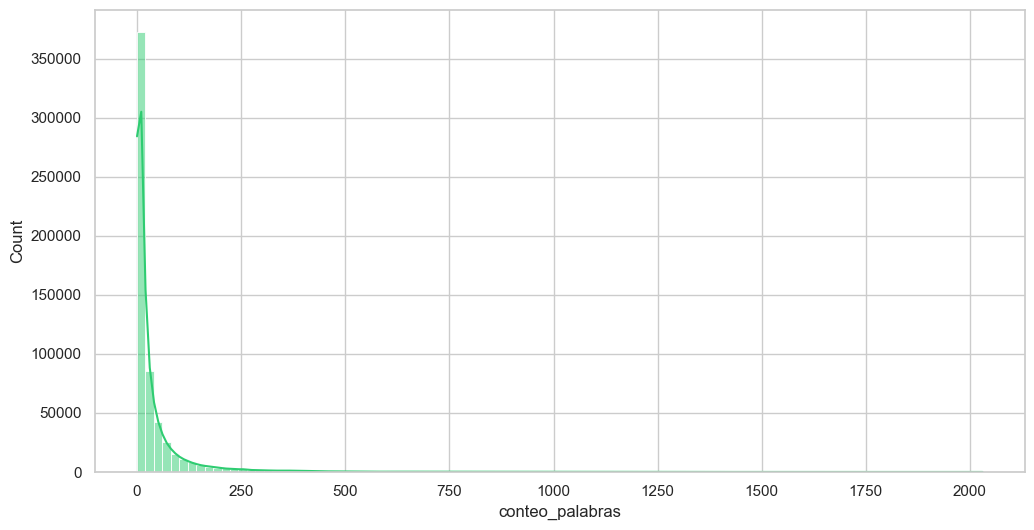

In [87]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.histplot(data=df_limpio, x='conteo_palabras', bins=100, kde=True, color='#2ecc71')

In [88]:
df_limpio.shape

(598749, 23)

In [89]:

min_palabras = 15 
max_palabras = 200 

df_limpio = df_limpio[(df_limpio['conteo_palabras'] >= min_palabras) & (df_limpio['conteo_palabras'] <= max_palabras)].copy()


print(f"restante: {len(df_limpio)}")

restante: 249468


# clusterizar

In [90]:
df_limpio['recomendado'].value_counts()

recomendado
1    218731
0     30737
Name: count, dtype: int64

In [91]:
df_positivos = df_limpio[df_limpio['recomendado'] == 1].copy()
df_negativos = df_limpio[df_limpio['recomendado'] == 0].copy()


## usar modelo

In [92]:
from sentence_transformers import SentenceTransformer

modelo_bert = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## negativo

In [93]:
df_negativos['resena_limpia']

5                                                                                                                                                                este juego me ha hecho darme cuenta que no sirvo para nada, mucho menos matar gente inocente. posdata la actualizacion de los cartuchos es una verga
32                                                                                                                                     puros chiteros. injugable, era el mejor shoter de la historia y ahora es lo peor. ya no dan ganas de jugar. pero vale prefiere reformar los cargadores antes que el anticheat.
36                                                                                                                                                                                               saquen la boludez de los cargadores hdrpt pero pa el anticheat no mueven el ogt manga de garcas, valve alcahuete hdp
44                                                                    

In [94]:
textos = df_negativos['resena_limpia'].tolist()

embeddings_bert = modelo_bert.encode(
    textos,
    batch_size=64,
    device='cuda',
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_bert.shape

Batches:   0%|          | 0/481 [00:00<?, ?it/s]

(30737, 768)

In [95]:
reducer = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=31,
)

In [96]:
embeddings_umap = reducer.fit_transform(embeddings_bert)

c:\Proyectos\GameLens\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [97]:
# scaler = StandardScaler()
# embeddings_umap_scaled = scaler.fit_transform(embeddings_umap)

In [98]:
# embeddings_umap_scaled.shape

In [99]:
df_neg = df_limpio[df_limpio['recomendado'] == 0]
print(df_neg['conteo_palabras'].describe(percentiles=[.25,.5,.75,.90]))

count   30,737.00
mean        59.35
std         43.39
min         15.00
25%         26.00
50%         44.00
75%         80.00
90%        127.00
max        200.00
Name: conteo_palabras, dtype: float64


In [100]:
for mcs in [200,175,150,140,130,120,110,100]:
    labels_test = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        metric='euclidean',
        cluster_selection_method='eom',).fit_predict(embeddings_umap)
    
    conteo = pd.Series(labels_test).value_counts().sort_index()
    n_c = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_r = (labels_test == -1).sum()
    print(f'\nmcs={mcs}: {n_c} clusters  ruido={n_r:,} ({n_r/len(labels_test)*100:.1f}%)')
    print(conteo.to_string())
    print('---')


mcs=200: 4 clusters  ruido=691 (2.2%)
-1      691
 0      282
 1      210
 2      720
 3    28834
---

mcs=175: 4 clusters  ruido=691 (2.2%)
-1      691
 0      282
 1      210
 2      720
 3    28834
---

mcs=150: 4 clusters  ruido=691 (2.2%)
-1      691
 0      282
 1      210
 2      720
 3    28834
---

mcs=140: 4 clusters  ruido=691 (2.2%)
-1      691
 0      282
 1      210
 2      720
 3    28834
---

mcs=130: 25 clusters  ruido=19,318 (62.8%)
-1     19318
 0       282
 1       210
 2       720
 3       198
 4       453
 5       294
 6       306
 7       193
 8       492
 9       142
 10      630
 11      592
 12     1554
 13      262
 14      389
 15      148
 16      423
 17      203
 18      551
 19      184
 20      913
 21      245
 22     1398
 23      430
 24      207
---

mcs=120: 25 clusters  ruido=19,318 (62.8%)
-1     19318
 0       282
 1       210
 2       720
 3       198
 4       453
 5       294
 6       306
 7       193
 8       492
 9       142
 10      630
 1

In [101]:
labels = hdbscan.HDBSCAN(
    min_cluster_size=130,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',).fit_predict(embeddings_umap)

In [102]:
df_negativos['cluster'] = labels

In [103]:
for cid in sorted(df_negativos['cluster'].unique()):
    n = (df_negativos['cluster'] == cid).sum()
    muestra = df_negativos[df_negativos['cluster'] == cid]['resena_limpia'].sample(20, random_state=31)
    print(f'\n=== Cluster {cid} ({n:,} reseñas) ===')
    for r in muestra:
        print(f'  - {r[:200]}')


=== Cluster -1 (19,318 reseñas) ===
  - tengo sensaciones divididas sobre signalis. no hay ningún combate desafiante, ni siquiera los jefes. al final la mejor táctica es pasar de largo ignorando cualquier bicho. la cantidad de backtracking 
  - vengo de jugar muchas horas al pay day 2 y de hecho no puedo de dar una sola opinión del 3 por que ni siquiera me deja crear una cuenta en nubula para poder iniciar sesión por lo cual no me deja jugar
  - literal primera partida y me insultaron de formas que ni en risa habia visto carnal relajense estan viendo a alguien nivel 3 en una normal y salen con insultos brutales y encima de flameo se van afk p
  - algo falta de contenido pero no deja de ser una buena opcion a diferencias de cuantos refricall of dutys existen y con la tonteria de lo mas quemado en los royale como fornite en otras palabras vale l
  - 11 horas seguidas de juego para que al otro día accidentalmente presionar el botón de "nueva partida" y que automáticamente se borrara la p

In [104]:

textos_por_cluster = df_negativos.groupby('cluster')['resena_limpia'].apply(lambda x: ' '.join(x)).reset_index()

tfidf = TfidfVectorizer(max_features=50000, max_df=0.5, min_df=2)
matriz = tfidf.fit_transform(textos_por_cluster['resena_limpia'])
palabras = tfidf.get_feature_names_out()

top_n = 20
for i, row in textos_por_cluster.iterrows():
    cid = row['cluster']
    scores = matriz[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    top_palabras = [palabras[j] for j in top_idx]
    n = (df_negativos['cluster'] == cid).sum()
    print(f'Cluster {cid} ({n:,}): {", ".join(top_palabras)}')

Cluster -1 (19,318): sonic, resident, peleas, remake, terror, evil, ark, escenarios, miedo, souls, servers, windows, aburridos, matan, dark, sienten, mejorable, pareció, ideas, secundarias
Cluster 0 (282): latinoamerica, servers, server, sudamérica, sur, brasil, sudamerica, argentina, america, latinos, américa, latinoamérica, latino, latinoamericanos, ms, 200ms, europa, paises, región, norte
Cluster 1 (210): zombies, zombie, zombis, rising, left, zombi, hordas, 04, 42, multi, survival, nexon, vs, army, saltar, golpes, dying, supervivencia, sobrevivir, item
Cluster 2 (720): toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces, undertale, españa, traduccion, visión, traducido, israel, japonés, traducirlo, castellano, lengua
Cluster 3 (198): emulador, ports, ps2, hd, gamecube, adventure, 360, ps3, collection, psp, sonic, remaster, ps4, fixes, playstation, fantasy, switch, ratón, resolución, sega
Cluster 4 (453): teclas, volante, ratón, reconoce, compatibili

In [105]:
top_n = 10
cluster_keywords = {}

for i, row in textos_por_cluster.iterrows():
    cid = row['cluster']
    if cid == -1:  # ruido sin clasificar
        cluster_keywords[cid] = None
        continue
    scores = matriz[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    top_palabras = [palabras[j] for j in top_idx]
    cluster_keywords[cid] = ', '.join(top_palabras)

In [106]:
cluster_keywords

{-1: None,
 0: 'latinoamerica, servers, server, sudamérica, sur, brasil, sudamerica, argentina, america, latinos',
 1: 'zombies, zombie, zombis, rising, left, zombi, hordas, 04, 42, multi',
 2: 'toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces',
 3: 'emulador, ports, ps2, hd, gamecube, adventure, 360, ps3, collection, psp',
 4: 'teclas, volante, ratón, reconoce, compatibilidad, controls, raton, tecla, compatible, botón',
 5: 'rally, conducción, dirt, carreras, coches, f1, forza, volante, pistas, coche',
 6: 'fifa, pes, futbol, fc, fútbol, partidos, soccer, goles, ultimate, licencias',
 7: 'spyware, hacks, hacker, hack, eula, cheat, wall, hakers, consumidor, infestado',
 8: 'origin, windows, linux, drm, ap, key, steamdeck, edition, normalito, slug',
 9: 'arruinan, borran, corrijan, detecta, progresar, volando, adentro, reloaded, paracaídas, ias',
 10: 'mejorable, aburre, pareció, análisis, monótono, monotono, miedo, aburridos, supervivencia, aburriend

In [107]:

df_negativos['palabras_clave_neg'] = df_negativos['cluster'].map(cluster_keywords)


In [108]:
df_negativos['palabras_clave_neg'].value_counts()

palabras_clave_neg
ryzen, gb, bajones, rx, gpu, procesador, estables, 60fps, 16gb, dls                                         1554
protagonista, narrativa, dragon, decisiones, ambientación, lineal, escenarios, finales, historias, anime    1398
concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama                                             913
toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces                         720
mejorable, aburre, pareció, análisis, monótono, monotono, miedo, aburridos, supervivencia, aburriendo        630
argentina, edition, sims, precios, deluxe, argentinos, impuestos, ars, ofertas, pague                        592
servers, server, caen, desconecta, hostear, privado, dedicados, oficiales, vacios, muertos                   551
origin, windows, linux, drm, ap, key, steamdeck, edition, normalito, slug                                    492
teclas, volante, ratón, reconoce, compatibilidad, controls, raton, tecla, com

In [109]:
df_negativos[['resena_id', 'cluster', 'palabras_clave_neg']].head(10)

,resena_id,cluster,palabras_clave_neg
5,222892908,-1,NaN
32,222762469,-1,NaN
36,222738798,-1,NaN
44,222701339,-1,NaN
49,222641111,7,"spyware, hacks, hacker, hack, eula, cheat, wall, hakers, consumidor, infestado"
50,222640992,20,"concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama"
60,222596476,-1,NaN
79,222459219,2,"toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces"
113,222340090,20,"concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama"
136,222226348,2,"toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces"


## Positivas

In [110]:
df_positivos['resena_limpia']


8                                                                                      lo probé porque vengo de valorant, era main sage pero ya no me gusta más ese juego. quise probar algo del mismo género y me gustó mucho, apoyo bastante, así que si quieren jugar tienen una sniper disponible expresion feliz
12                                                                                                                                              es muy buen juego si te gustan los shoters y no necesita un pc muy potente para correrlo con buenos gráficos es de este nivel competitivo muy divertido y entretenido
14                                                                                                                                                                                                                    muy bueno la verdad, llegare a 10k y se lo dedicare a toda mia familia y sobre todo a totonsita
18                                                                    

In [111]:
textos_pos = df_positivos['resena_limpia'].tolist()

embeddings_bert_pos = modelo_bert.encode(
    textos_pos,
    batch_size=64,
    device='cuda',
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_bert_pos.shape

Batches:   0%|          | 0/3418 [00:00<?, ?it/s]

(218731, 768)

In [112]:
reducer_pos = umap.UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.05,
    metric='cosine',
    random_state=31,
)

In [113]:
embeddings_umap_pos = reducer_pos.fit_transform(embeddings_bert_pos)


c:\Proyectos\GameLens\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [114]:
for mcs in [50000,20000,10000,700,600,550,500,450,400,350,300]:
    labels_test = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        metric='euclidean',
        cluster_selection_method='eom',).fit_predict(embeddings_umap_pos)
    
    conteo = pd.Series(labels_test).value_counts().sort_index()
    n_c = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_r = (labels_test == -1).sum()
    print(f'\nmcs={mcs}: {n_c} clusters ruido={n_r:,} ({n_r/len(labels_test)*100:.1f}%)')
    print(conteo.to_string())
    print('---')


mcs=50000: 0 clusters ruido=218,731 (100.0%)
-1    218731
---

mcs=20000: 2 clusters ruido=164,313 (75.1%)
-1    164313
 0     33598
 1     20820
---

mcs=10000: 2 clusters ruido=164,313 (75.1%)
-1    164313
 0     33598
 1     20820
---

mcs=700: 4 clusters ruido=4,977 (2.3%)
-1      4977
 0      1172
 1       823
 2      2303
 3    209456
---

mcs=600: 4 clusters ruido=4,977 (2.3%)
-1      4977
 0      1172
 1       823
 2      2303
 3    209456
---

mcs=550: 4 clusters ruido=4,977 (2.3%)
-1      4977
 0      1172
 1       823
 2      2303
 3    209456
---

mcs=500: 4 clusters ruido=4,977 (2.3%)
-1      4977
 0      1172
 1       823
 2      2303
 3    209456
---

mcs=450: 2 clusters ruido=632 (0.3%)
-1       632
 0       461
 1    217638
---

mcs=400: 2 clusters ruido=632 (0.3%)
-1       632
 0       461
 1    217638
---

mcs=350: 43 clusters ruido=154,627 (70.7%)
-1     154627
 0        461
 1        358
 2       1172
 3        823
 4       2303
 5        703
 6        523
 7     

In [115]:
for mcs in [300,200,150,100,50,25]:
    labels_test = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        metric='euclidean',
        cluster_selection_method='eom',).fit_predict(embeddings_umap_pos)
    
    conteo = pd.Series(labels_test).value_counts().sort_index()
    n_c = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_r = (labels_test == -1).sum()
    print(f'\nmcs={mcs}: {n_c} clusters ruido={n_r:,} ({n_r/len(labels_test)*100:.1f}%)')
    print(conteo.to_string())
    print('---')


mcs=300: 51 clusters ruido=154,304 (70.5%)
-1     154304
 0        329
 1        461
 2        358
 3       1172
 4        823
 5       2303
 6        344
 7        318
 8        703
 9        523
 10       472
 11      1451
 12      1284
 13      2776
 14       693
 15       518
 16      1965
 17       367
 18      2137
 19       898
 20       346
 21       493
 22       500
 23       602
 24       516
 25       372
 26      1874
 27       508
 28       317
 29       591
 30      1734
 31       780
 32      1367
 33       523
 34      5943
 35       535
 36       404
 37      1183
 38      2074
 39       505
 40       881
 41      1058
 42       791
 43       360
 44      1934
 45      4984
 46      4336
 47       368
 48      5376
 49      2934
 50       343
---

mcs=200: 76 clusters ruido=153,523 (70.2%)
-1     153523
 0        329
 1        461
 2        261
 3        223
 4        358
 5        231
 6        245
 7        243
 8        676
 9        227
 10       203
 11       82

In [116]:
labels_pos = hdbscan.HDBSCAN(
    min_cluster_size=300,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',).fit_predict(embeddings_umap_pos)

In [117]:
df_positivos['cluster'] = labels_pos

In [118]:
for cid in sorted(df_positivos['cluster'].unique()):
    n = (df_positivos['cluster'] == cid).sum()
    muestra = df_positivos[df_positivos['cluster'] == cid]['resena_limpia'].sample(10, random_state=31)
    print(f'\n=== Cluster {cid} ({n:,} reseñas) ===')
    for r in muestra:
        print(f'  - {r[:100]}')


=== Cluster -1 (154,304 reseñas) ===
  - de los desarrolladores que crearon ftl. un estilo de gráficos sencillo pero lo suficientemente detal
  - en lo personal risk of rain returns me trajo una gran sensación de nostalgia porque a los 14 años ju
  - un juego para pc s del gobierno, sirve pa juegar con los amigos si ninguno tiene consola o pc buena
  - muy buen juego por parte de frictional games, la verdad pasaron ya 10 años y sigue sintiéndose fresc
  - es un juego muy bonito, ojalá fuera más largo y con nivel de dificultad conforme avanzas.
  - la verdad me sorprendio, ademas del arte, su historia es interesante y en las decisiones que se toma
  - es un muy buen juego, me gusta su arte lovecraftiano mezclado con la ambientación souls.
  - muy buen juego, más si esta estrenado te ayuda mucho a calmarte, es relajado y algo simple, pero com
  - totalmente recomendado, me encanto la estetica y la historia, ahora toca jugar la secuela expresion_
  - un verdadero reto pasarse este juego.

In [119]:

textos_por_cluster_pos = df_positivos.groupby('cluster')['resena_limpia'].apply(lambda x: ' '.join(x)).reset_index()

tfidf_pos = TfidfVectorizer(max_features=50000, max_df=0.5, min_df=2)
matriz_pos = tfidf_pos.fit_transform(textos_por_cluster_pos['resena_limpia'])
palabras_pos = tfidf_pos.get_feature_names_out()

top_n = 5
for i, row in textos_por_cluster_pos.iterrows():
    cid = row['cluster']
    scores = matriz_pos[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    top_palabras = [palabras_pos[j] for j in top_idx]
    n = (df_positivos['cluster'] == cid).sum()
    print(f'Cluster {cid} ({n:,}): {", ".join(top_palabras)}')

Cluster -1 (154,304): balatro, cuadrado, hack, novela, slash
Cluster 0 (329): paint, adolescentes, mb, average, grind
Cluster 1 (461): bioshock, borderlands, rapture, infinite, dady
Cluster 2 (358): fifa, fútbol, futbol, pes, efotball
Cluster 3 (1,172): batman, arkham, spiderman, asylum, ark
Cluster 4 (823): star, wars, lego, jedi, sable
Cluster 5 (2,303): zombies, zombis, zombie, nazis, wolfenstein
Cluster 6 (344): alien, aliens, isolation, predator, xenomorfo
Cluster 7 (318): witcher, poter, hogwarts, harry, brujo
Cluster 8 (703): gatos, gato, gatitos, gatito, cat
Cluster 9 (523): builder, cities, simcity, skylines, builders
Cluster 10 (472): mazo, mazos, balatro, poker, magic
Cluster 11 (1,451): soulslike, darksiders, devil, may, soul
Cluster 12 (1,284): metroidvania, hollow, knight, metro, metroidvanias
Cluster 13 (2,776): f1, rally, volante, conducción, coches
Cluster 14 (693): subnautica, tiburón, barcos, pesca, mar
Cluster 15 (518): dragon, ball, dragón, age, budokai
Cluster 16 

In [120]:
for cid in sorted(df_positivos['cluster'].unique()):
    if cid == -1:
        continue
    muestra = (df_positivos[df_positivos['cluster'] == cid]
               .groupby('titulo')
               .size()
               .sort_values(ascending=False)
               .head(10))
    n = (df_positivos['cluster'] == cid).sum()
    print(f'\n=== Cluster {cid} ({n:,} reseñas) ===')
    print(muestra.to_string())


=== Cluster 0 (329 reseñas) ===
titulo
Grand Theft Auto: San Andreas                           4
The Witcher 2: Assassins of Kings - Enhanced Edition    3
Shadow of the Tomb Raider                               3
The Crew 2                                              3
Hellblade: Senua's Sacrifice                            3
Killing Floor 2                                         3
Ultimate Chicken Horse                                  2
Thief                                                   2
The Binding of Isaac: Rebirth                           2
A Way Out                                               2

=== Cluster 1 (461 reseñas) ===
titulo
BioShock Infinite              74
BioShock Remastered            56
BioShock 2 Remastered          55
Borderlands 3                  48
Borderlands: The Pre-Sequel    34
BioShock 2                     31
Borderlands 2                  27
BioShock                       18
Tales from the Borderlands     13
Tiny Tina's Wonderlands        10


In [121]:
titulos = df_positivos['titulo'].unique()

In [122]:
stop_titulos = set()
for titulo in titulos:
    # limpiar y tokenizar cada título
    titulo_limpio = titulo.lower()
    titulo_limpio = re.sub(r'[^a-záéíóúüñ\s]', ' ', titulo_limpio)
    palabras_titulo = [p for p in titulo_limpio.split() if len(p) > 2]
    stop_titulos.update(palabras_titulo)

print(f'Palabras de títulos a excluir: {len(stop_titulos):,}')

Palabras de títulos a excluir: 5,150


In [123]:
tfidf_pos = TfidfVectorizer(
    max_features=50000,
    max_df=0.5,
    min_df=2,
    stop_words=list(stop_titulos)
)
matriz_pos = tfidf_pos.fit_transform(textos_por_cluster_pos['resena_limpia'])
palabras_pos = tfidf_pos.get_feature_names_out()


In [124]:
top_n = 10
for i, row in textos_por_cluster_pos.iterrows():
    cid = row['cluster']
    if cid == -1:
        continue
    scores = matriz_pos[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    top_palabras = [palabras_pos[j] for j in top_idx]
    n = (df_positivos['cluster'] == cid).sum()
    print(f'Cluster {cid} ({n:,}): {", ".join(top_palabras)}')

Cluster 0 (329): adolescentes, mb, grind, nasa, decepciónmuy, audiencia, 2decepción8, gráficosdecepción, empañan, soundtracdecepción
Cluster 1 (461): dady, minerva, vigorizadores, columbia, plásmidos, plasmidos, claptrap, handsome, elizabeth, burial
Cluster 2 (358): fútbol, futbol, efotball, fifas, fc, licencias, ligas, estadios, camisetas, fotball
Cluster 3 (1,172): spiderman, superheroes, superhéroes, rocksteady, joker, villanos, spidedecepciónan, dc, murciélago, araña
Cluster 4 (823): legos, batlefront, kotor, planetas, cal, naves, espaciales, sables, kestis, peliculas
Cluster 5 (2,303): zombis, nazis, hordas, parkour, apocalipsis, hitler, custom, horda, multi, supervivientes
Cluster 6 (344): xenomorfo, alíen, ripley, depredador, octavo, pasajero, 1979, peliculas, alienígena, alienígenas
Cluster 7 (318): poter, brujo, libros, hechizos, geralt, mágico, escoba, bruja, alrededores, quiditch
Cluster 8 (703): gatos, gatitos, gatito, gata, pet, felino, maullar, michis, adorable, miau
Clus

In [125]:
df_positivos['cluster_pos'] = df_positivos['cluster']
df_negativos['cluster_neg'] = df_negativos['cluster']

In [126]:
CLUSTERS_EXCLUIR = {-1, 48, 18, 29, 0, 45}

def recomendar_juegos(juego_id, df_pos, top_n_clusters=3, top_n_juegos=5):
    inicio = time.time()
    
    resenas_juego = df_pos[df_pos['juego_id'] == juego_id]
    if resenas_juego.empty:
        print('No hay reseñas positivas para este juego')
        return
    
    titulo = resenas_juego['titulo'].iloc[0]
    
    # verificar cobertura
    total = len(resenas_juego)
    ruido = (resenas_juego['cluster_pos'] == -1).sum()
    pct_ruido = ruido / total
    
    if pct_ruido > 0.7:
        print(f'\nJuego: {titulo}')
        print(f'⚠️ {pct_ruido*100:.0f}% de reseñas sin clasificar — recomendaciones no disponibles')
        return
    
    clusters_juego = (resenas_juego[~resenas_juego['cluster_pos'].isin(CLUSTERS_EXCLUIR)]
                      ['cluster_pos']
                      .value_counts(normalize=True)
                      .head(top_n_clusters))
    
    if clusters_juego.empty:
        print(f'\nJuego: {titulo}')
        print('⚠️ Sin clusters válidos para recomendar')
        return
    
    tam_clusters = df_pos['cluster_pos'].value_counts()
    
    recomendaciones = {}
    for cluster_id, pct in clusters_juego.items():
        peso = pct / (tam_clusters[cluster_id] ** 0.3)
        
        juegos_cluster = (df_pos[(df_pos['cluster_pos'] == cluster_id) & 
                                  (df_pos['juego_id'] != juego_id)]
                          .groupby(['juego_id', 'titulo'])
                          .size()
                          .sort_values(ascending=False)
                          .head(top_n_juegos))
        
        for (jid, tit), count in juegos_cluster.items():
            if jid not in recomendaciones:
                recomendaciones[jid] = {'titulo': tit, 'score': 0}
            recomendaciones[jid]['score'] += count * peso
    
    resultado = sorted(recomendaciones.values(), 
                      key=lambda x: x['score'], reverse=True)[:top_n_juegos]
    
    fin = time.time()
    
    print(f'\nJuego: {titulo}')
    print(f'Clusters principales: {dict(clusters_juego.round(2))}')
    print(f'\nRecomendaciones:')
    for r in resultado:
        print(f'  - {r["titulo"]} (score: {r["score"]:.2f})')
    print(f'\nTiempo: {(fin-inicio)*1000:.1f}ms')

In [127]:
# prueba con un juego
df_positivos[['titulo','juego_id']].value_counts().head(60)


titulo                                            juego_id
Crimson Desert                                    1972        493
Gris                                              265         487
Hellblade: Senua's Sacrifice                      103         482
Darkest Dungeon                                   337         460
Life is Strange                                   36          447
Silent Hill 2                                     567         447
Dispatch                                          697         427
Horizon Zero Dawn: Complete Edition               715         424
Kenshi                                            1767        422
MiSide                                            1061        421
Outer Wilds                                       159         421
Black Mesa                                        266         413
Katana Zero                                       436         408
Sleeping Dogs: Definitive Edition                 587         398
RimWorld         

In [128]:
recomendar_juegos(120, df_positivos)


Juego: Star Wars Jedi: Fallen Order
Clusters principales: {4: np.float64(0.72), 34: np.float64(0.07), 11: np.float64(0.05)}

Recomendaciones:
  - Star Wars Jedi: Survivor (score: 7.04)
  - LEGO Star Wars: The Skywalker Saga (score: 7.04)
  - Star Wars: Battlefront II (score: 3.86)
  - LEGO Marvel Super Heroes (score: 3.57)
  - Star Wars: Knights of the Old Republic (score: 3.47)

Tiempo: 13.8ms


In [129]:
juego_id_cp = df_positivos[df_positivos['titulo'].str.contains('Cyberpunk')]['juego_id'].iloc[0]

print(df_positivos[df_positivos['juego_id'] == juego_id_cp]['cluster_pos']
      .value_counts(normalize=True)
      .head(10)
      .round(3))

cluster_pos
-1    0.86
 48   0.03
 45   0.02
 38   0.01
 34   0.01
 36   0.01
 44   0.01
 33   0.01
 16   0.01
 0    0.01
Name: proportion, dtype: float64


Esto se puede usar como forma de etiquetar jeugos de acuerdo a la opcion de las personas, pero para que sea bueno hay que limpiar aun mas las reseñas

## Agrupar resenas por topicos conocidos

In [176]:
descripciones_temas = {
    'historia':      'la historia es una obra maestra, el guion y la narrativa te atrapan por completo, y los personajes te hacen llorar o emocionarte',
    'gameplay':      'la jugabilidad es excelente, el combate es muy fluido, las mecánicas son divertidas y los controles responden a la perfección',
    'graficos':      'visualmente es hermoso, los gráficos son una locura, el diseño artístico y la ambientación de los paisajes son impresionantes',
    'musica':        'el soundtrack es épico, la banda sonora es una joya y la música te sumerge por completo en la atmósfera del juego',
    'multijugador':  'es el mejor juego para jugar con amigos, el cooperativo es súper divertido y te ríes a carcajadas en el multijugador',
    'mundo_abierto': 'el mapa es enorme, la exploración del mundo abierto es inmersiva y está lleno de secretos y misiones por descubrir',
    'dificultad':    'es un juego difícil y muy desafiante, pero aprender los patrones y superar los retos te da una satisfacción increíble',
    'precio':        'vale cada centavo, lo compré en oferta y es una excelente inversión, la relación calidad precio es inmejorable',
    'nostalgia':     'me trae muchísima nostalgia, es el juego de mi infancia, un clásico hermoso que me hace recordar viejos tiempos',
    'duracion':      'tiene muchísimo contenido, la campaña es larga y te da cientos de horas de entretenimiento sin aburrirte',
    'rejugabilidad': 'tiene una rejugabilidad infinita, puedes probar distintas builds y cada nueva partida es una experiencia totalmente diferente',
    'optimizacion':  'está excelentemente optimizado, corre a fps estables y sin tirones de lag incluso en una pc humilde o de bajos recursos',
    'accesibilidad': 'es un juego para relajarse, muy fácil de aprender, ideal para pasar un rato chill con controles súper intuitivos',
    'adictivo':      'es droga pura, es súper adictivo, el farmeo te engancha y cuando te das cuenta ya le metiste muchísimas horas y no puedes parar',
}


In [177]:

textos_temas = list(descripciones_temas.values())
nombres_temas = list(descripciones_temas.keys())

embeddings_temas = modelo_bert.encode(
    textos_temas,
    device='cuda',
    normalize_embeddings=True,
    show_progress_bar=False
)

In [178]:
from sklearn.metrics.pairwise import cosine_similarity

similitudes_bert = cosine_similarity(embeddings_bert_pos, embeddings_temas)

similitudes_norm = similitudes_bert.copy()
for j in range(similitudes_norm.shape[1]):
    col = similitudes_norm[:, j]
    similitudes_norm[:, j] = (col - col.mean()) / col.std()

In [179]:
similitudes_norm

array([[-0.9799789 ,  0.59507936, -0.82858217, ..., -0.20985693,
         1.0173925 ,  0.3362932 ],
       [-0.7536979 ,  2.1440876 ,  0.73195386, ...,  2.3454924 ,
         2.1271482 , -0.00670356],
       [-0.8722013 , -1.7053232 , -1.1491723 , ..., -0.41062525,
        -1.6631166 ,  0.41726014],
       ...,
       [ 0.6243016 ,  0.18455207,  2.665534  , ..., -0.10674215,
        -0.28342402,  1.0442858 ],
       [-1.4393891 , -0.2610552 , -0.81797916, ...,  0.9395333 ,
         0.66863143, -0.51091725],
       [-0.6611638 ,  1.1319416 , -0.04161757, ...,  0.6634755 ,
         0.18113188, -1.2304515 ]], shape=(218731, 14), dtype=float32)

In [207]:
UMBRAL_NORM = 0.6
UMBRAL_BERT = 0.45

temas_asignados = []
for i in range(len(df_positivos)):
    scores_norm = similitudes_norm[i]
    scores_bert = similitudes_bert[i]
    top3 = scores_norm.argsort()[::-1][:3]
    temas_validos = [(nombres_temas[j], round(float(scores_bert[j]), 3))
                     for j in top3
                     if scores_norm[j] >= UMBRAL_NORM
                     and scores_bert[j] >= UMBRAL_BERT]
    temas_asignados.append(temas_validos)

df_positivos['temas'] = temas_asignados
df_positivos[['titulo','resena_limpia','temas']]

,titulo,resena_limpia,temas
8,Counter-Strike 2,"lo probé porque vengo de valorant, era main sage pero ya no me gusta más ese juego. quise probar algo del mismo género y me gustó mucho, apoyo bastante, así que si quieren jugar tienen una sniper disponible expresion feliz","[(accesibilidad, 0.562), (multijugador, 0.559), (dificultad, 0.521)]"
12,Counter-Strike 2,es muy buen juego si te gustan los shoters y no necesita un pc muy potente para correrlo con buenos gráficos es de este nivel competitivo muy divertido y entretenido,"[(optimizacion, 0.487), (gameplay, 0.65), (accesibilidad, 0.717)]"
14,Counter-Strike 2,"muy bueno la verdad, llegare a 10k y se lo dedicare a toda mia familia y sobre todo a totonsita",[]
18,Counter-Strike 2,"si bien es un buen juego, nunca va a poder superar a lo que era el sc go",[]
39,Counter-Strike 2,es muy buen juego pero hay mucha gente con chetos que arruina totalmente la experiencia,"[(adictivo, 0.501), (dificultad, 0.639)]"
...,...,...,...
599398,Shroud of the Avatar: Forsaken Virtues,"i love this game is so beautiful in all aspects, i think if the programers can make an option for chose ""rendering draw distance or rendering draw chunks"" and this option maybe player can chose 1 to 10 or 50 to 100 of render distance, the game in a simple way will be optimized and the ram will b...","[(rejugabilidad, 0.49)]"
599399,Shroud of the Avatar: Forsaken Virtues,antes no podia jugar por los fps bajos y ahora tengo buenos fps... buena update,"[(optimizacion, 0.667)]"
599401,Dream,"una experiencia bastante interesante, sobre todo si eres de los que les gusta explorar , el sountrack es maravilloso","[(mundo_abierto, 0.541), (graficos, 0.579), (duracion, 0.535)]"
599403,Deep Black,para poder jugar este juego en 2021 y te aparece error o pantalla negra tienes que bloquearlo en firewall de windows ...sigan los pasos de ese link y listo obvio en lugar de firefox como dice ahi pues es el programa depblack.exe y listo abrir el juego desde steam en tu lista de biblioteca y solu...,"[(accesibilidad, 0.514)]"


In [208]:
# resumen final
con_tema = df_positivos['temas'].apply(len) > 0
print(f'Con al menos 1 tema: {con_tema.sum():,} ({con_tema.mean()*100:.1f}%)')
print(f'Sin tema: {(~con_tema).sum():,} ({(~con_tema).mean()*100:.1f}%)')

from collections import Counter
todos_temas = [tema for lista in df_positivos['temas'] for tema, _ in lista]
dist = Counter(todos_temas)
total = sum(dist.values())
print('\nDistribución final de temas:')
for tema, count in sorted(dist.items(), key=lambda x: -x[1]):
    print(f'{tema}: {count:,} ({count/total*100:.1f}%)')

Con al menos 1 tema: 154,332 (70.6%)
Sin tema: 64,399 (29.4%)

Distribución final de temas:
dificultad: 36,190 (11.9%)
accesibilidad: 33,683 (11.0%)
multijugador: 33,340 (10.9%)
musica: 31,384 (10.3%)
nostalgia: 30,158 (9.9%)
rejugabilidad: 28,992 (9.5%)
gameplay: 28,084 (9.2%)
historia: 19,270 (6.3%)
duracion: 18,818 (6.2%)
precio: 18,483 (6.1%)
graficos: 14,066 (4.6%)
adictivo: 5,285 (1.7%)
optimizacion: 5,166 (1.7%)
mundo_abierto: 2,243 (0.7%)


In [212]:
df_negativos[~df_negativos['palabras_clave_neg'].isnull()]['palabras_clave_neg']

49               spyware, hacks, hacker, hack, eula, cheat, wall, hakers, consumidor, infestado
50                             concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama
79         toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces
113                            concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama
136        toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces
                                                  ...                                          
599357                      zombies, zombie, zombis, rising, left, zombi, hordas, 04, 42, multi
599363                         concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama
599396    argentina, edition, sims, precios, deluxe, argentinos, impuestos, ars, ofertas, pague
599400                      ryzen, gb, bajones, rx, gpu, procesador, estables, 60fps, 16gb, dls
599408     toby, traducción, idiomas, in

# Guardar en base

In [213]:
import sqlite3
import json

conn = sqlite3.connect(DB_PATH)

conn.execute("ALTER TABLE Hist_Steam_Reviews ADD COLUMN palabras_clave_neg TEXT DEFAULT NULL")
conn.execute("ALTER TABLE Hist_Steam_Reviews ADD COLUMN temas_pos TEXT DEFAULT NULL")
conn.commit()

df_neg_update = df_negativos[['resena_id', 'palabras_clave_neg']].dropna()
conn.executemany(
    "UPDATE Hist_Steam_Reviews SET palabras_clave_neg = ? WHERE resena_id = ?",
    [(row['palabras_clave_neg'], row['resena_id']) for _, row in df_neg_update.iterrows()]
)
conn.commit()
print(f'Negativos guardados: {len(df_neg_update):,}')

df_pos_update = df_positivos[df_positivos['temas'].apply(len) > 0][['resena_id', 'temas']]
df_pos_update['temas_json'] = df_pos_update['temas'].apply(json.dumps)
conn.executemany(
    "UPDATE Hist_Steam_Reviews SET temas_pos = ? WHERE resena_id = ?",
    [(row['temas_json'], row['resena_id']) for _, row in df_pos_update.iterrows()]
)
conn.commit()
print(f'Positivos guardados: {len(df_pos_update):,}')

conn.close()

Negativos guardados: 11,419
Positivos guardados: 154,332


In [216]:
conn = sqlite3.connect(DB_PATH)

# verificar negativos
print('=== Muestra negativos ===')
df_check_neg = pd.read_sql_query("""
    SELECT resena_id, recomendado, palabras_clave_neg 
    FROM Hist_Steam_Reviews 
    WHERE palabras_clave_neg IS NOT NULL 
    LIMIT 5
""", conn)
display(df_check_neg)

# verificar positivos
print('=== Muestra positivos ===')
df_check_pos = pd.read_sql_query("""
    SELECT resena_id, recomendado, temas_pos 
    FROM Hist_Steam_Reviews 
    WHERE temas_pos IS NOT NULL 
    LIMIT 5
""", conn)
display(df_check_pos)

# conteos
print('=== Conteos ===')
df_conteos = pd.read_sql_query("""
    SELECT 
        COUNT(*) as total,
        SUM(CASE WHEN palabras_clave_neg IS NOT NULL THEN 1 ELSE 0 END) as con_palabras_neg,
        SUM(CASE WHEN temas_pos IS NOT NULL THEN 1 ELSE 0 END) as con_temas_pos
    FROM Hist_Steam_Reviews
""", conn)
display(df_conteos)

conn.close()

=== Muestra negativos ===


,resena_id,recomendado,palabras_clave_neg
0,222641111,0,"spyware, hacks, hacker, hack, eula, cheat, wall, hakers, consumidor, infestado"
1,222640992,0,"concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama"
2,222459219,0,"toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces"
3,222340090,0,"concha, hijo, pario, wn, sexo, culero, putos, gordo, monos, mama"
4,222226348,0,"toby, traducción, idiomas, inglés, fox, traducir, latino, subtitulos, japones, voces"


=== Muestra positivos ===


,resena_id,recomendado,temas_pos
0,222861730,1,"[[""accesibilidad"", 0.562], [""multijugador"", 0.559], [""dificultad"", 0.521]]"
1,222843243,1,"[[""optimizacion"", 0.487], [""gameplay"", 0.65], [""accesibilidad"", 0.717]]"
2,222716874,1,"[[""adictivo"", 0.501], [""dificultad"", 0.639]]"
3,222544394,1,"[[""precio"", 0.482], [""dificultad"", 0.536], [""gameplay"", 0.467]]"
4,222453511,1,"[[""dificultad"", 0.63]]"


=== Conteos ===


,total,con_palabras_neg,con_temas_pos
0,600194,11419,154332
